# 🇱🇰 Sri Lankan Legal AI - Qwen3-8B Fine-tuning Pipeline

## Complete Training, Evaluation & Deployment Pipeline

This notebook provides a comprehensive pipeline for fine-tuning Qwen3-8B on Sri Lankan Labour & Employment Law with:

### Key Features:
- ✅ **Unsloth Optimization** - 2x faster training with 60% less memory
- ✅ **LoRA/QLoRA** - Parameter-efficient fine-tuning
- ✅ **Comprehensive Error Analysis** - Categorized by error type with actionable insights
- ✅ **Per-Category Performance** - Breakdown by legal area/scope category
- ✅ **Interactive HTML Reports** - Shareable with non-technical stakeholders
- ✅ **Model Comparison Framework** - Track improvements over versions
- ✅ **Confidence Intervals** - Statistical rigor for metrics
- ✅ **Latency Percentiles** - P50, P95, P99 for production readiness

### Best Practices Implemented:
- Stratified sampling for balanced test sets
- Bootstrap confidence intervals for metrics
- Edge case and adversarial example handling
- Data provenance and model lineage tracking
- Known limitations documentation

---
**Author**: Sri Lankan Legal AI Team  
**Version**: 2.0.0  
**Last Updated**: January 2026

## 1. Mount Google Drive & Setup Directories

In [1]:
# ============================================================================
# CELL 1: Mount Google Drive & Setup Directories
# ============================================================================
import os
import shutil


# Base directory for all outputs
GDRIVE_BASE = "/root/SLM_Legal_AI"

# Create directory structure
directories = [
    f"{GDRIVE_BASE}/checkpoints",
    f"{GDRIVE_BASE}/models",
    f"{GDRIVE_BASE}/models/versions",  # Model versioning
    f"{GDRIVE_BASE}/reports",
    f"{GDRIVE_BASE}/reports/html",  # Interactive HTML reports
    f"{GDRIVE_BASE}/reports/comparisons",  # Model comparison reports
    f"{GDRIVE_BASE}/logs",
    f"{GDRIVE_BASE}/data",  # Data provenance
    f"{GDRIVE_BASE}/errors",  # Error analysis logs
]

for directory in directories:
    os.makedirs(directory, exist_ok=True)

print("✅ Google Drive mounted successfully")
print(f"📁 Base directory: {GDRIVE_BASE}")
print(f"\n📂 Directory structure created:")
for d in directories:
    print(f"   └── {d.replace(GDRIVE_BASE, '')}")

✅ Google Drive mounted successfully
📁 Base directory: /root/SLM_Legal_AI

📂 Directory structure created:
   └── /checkpoints
   └── /models
   └── /models/versions
   └── /reports
   └── /reports/html
   └── /reports/comparisons
   └── /logs
   └── /data
   └── /errors


In [2]:
# ============================================================================
# CELL 2: Install Dependencies
# ============================================================================
print("📦 Installing dependencies...")

os.environ["UNSLOTH_VLLM_STANDBY"] = "1"

# Install Unsloth and dependencies
%uv pip install unsloth

%uv pip install vllm

# Additional dependencies
%uv pip install --quiet psutil

# Install visualization and analysis tools
%uv pip install matplotlib seaborn pandas scikit-learn

# Install NLP evaluation tools
%uv pip install nltk rouge-score sentence-transformers

# Install HTML report generation
%uv pip install jinja2 plotly kaleido

# Install statistical tools
%uv pip install scipy statsmodels

print("✅ All dependencies installed!")
print("\n📋 Installed packages:")
print("   • Unsloth (2x faster training)")
print("   • Matplotlib, Seaborn, Pandas")
print("   • ROUGE-Score, Sentence-Transformers")
print("   • Jinja2, Plotly (HTML reports)")
print("   • SciPy, Statsmodels (confidence intervals)")

📦 Installing dependencies...
Using Python 3.12.6 environment at: /usr/local
Resolved 86 packages in 428ms
⠙ Preparing packages... (0/35)
⠙ Preparing packages... (0/35)
⠙ Preparing packages... (0/35)
dill       ------------------------------ 14.89 KiB/116.86 KiB
⠙ Preparing packages... (0/35)
dill       ------------------------------ 14.89 KiB/116.86 KiB
⠙ Preparing packages... (0/35)
dill       ------------------------------ 14.89 KiB/116.86 KiB
nvidia-cuda-nvrtc-cu12 ------------------------------     0 B/83.96 MiB
⠙ Preparing packages... (0/35)
dill       ------------------------------ 14.89 KiB/116.86 KiB
nvidia-cuda-nvrtc-cu12 ------------------------------ 14.90 KiB/83.96 MiB
⠙ Preparing packages... (0/35)
dill       ------------------------------ 14.89 KiB/116.86 KiB
hf-transfer ------------------------------     0 B/3.39 MiB
nvidia-cuda-nvrtc-cu12 ------------------------------ 14.90 KiB/83.96 MiB
⠙ Preparing packages... (0/35)
dill       ------------------------------ 14.89 KiB

## 2. Install Dependencies

In [3]:
# Modal recommends uv in notebooks, but pip works too.
%uv pip install -U "typing_extensions>=4.14.0" pydantic pydantic-core

# Optional: if you already have a broken vLLM install, reinstall it cleanly
%uv pip uninstall vllm
%uv pip install -U vllm


Using Python 3.12.6 environment at: /usr/local
Resolved 5 packages in 62ms
Audited 5 packages in 0.18ms
Note: you may need to restart the kernel to use updated packages.
Using Python 3.12.6 environment at: /usr/local
Uninstalled 1 package in 81ms
 - vllm==0.13.0
Note: you may need to restart the kernel to use updated packages.
Using Python 3.12.6 environment at: /usr/local
Resolved 162 packages in 410ms
⠙ Preparing packages... (0/46)
⠙ Preparing packages... (0/46)
⠙ Preparing packages... (0/46)
pycparser  ------------------------------     0 B/115.37 KiB
⠙ Preparing packages... (0/46)
pycparser  ------------------------------ 14.88 KiB/115.37 KiB
⠙ Preparing packages... (0/46)
anyio      ------------------------------     0 B/110.93 KiB
pycparser  ------------------------------ 14.88 KiB/115.37 KiB
⠙ Preparing packages... (0/46)
anyio      ------------------------------ 14.89 KiB/110.93 KiB
pycparser  ------------------------------ 14.88 KiB/115.37 KiB
⠙ Preparing packages... (0/46)
cl

## 3. Import Libraries & Configuration

In [3]:
# ============================================================================
# CELL 3: Import Libraries & Configuration
# ============================================================================
from unsloth import FastLanguageModel
from unsloth.chat_templates import get_chat_template
from datasets import load_dataset, Dataset
from trl import SFTTrainer
from transformers import TrainingArguments, EarlyStoppingCallback, TrainerCallback
import torch
import json
import sys
import time
import re
import base64
from io import BytesIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from sklearn.model_selection import train_test_split, StratifiedKFold
from datetime import datetime
from typing import Dict, List, Tuple, Optional, Any
from dataclasses import dataclass, asdict
import warnings
warnings.filterwarnings('ignore')

# Statistical tools for confidence intervals
from scipy import stats
import hashlib

# For HTML reports
from jinja2 import Template

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Pipeline version for tracking
PIPELINE_VERSION = "2.0.0"
PIPELINE_TIMESTAMP = datetime.now().isoformat()

print("✅ Libraries imported successfully!")
print(f"📦 Pipeline Version: {PIPELINE_VERSION}")
print(f"🕐 Timestamp: {PIPELINE_TIMESTAMP}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
✅ Libraries imported successfully!
📦 Pipeline Version: 2.0.0
🕐 Timestamp: 2026-01-09T20:22:34.562677


## 4. GPU Validation & Environment Check

In [4]:
# ============================================================================
# CELL 4: GPU Validation & Environment Check
# ============================================================================
print("🖥️ ENVIRONMENT VALIDATION")
print("=" * 60)

if not torch.cuda.is_available():
    raise RuntimeError("❌ CUDA not available! Use GPU runtime: Runtime > Change runtime type > GPU")

gpu_props = torch.cuda.get_device_properties(0)
gpu_memory_gb = gpu_props.total_memory / 1024**3
gpu_memory_free = torch.cuda.mem_get_info()[0] / 1024**3

print(f"✅ GPU: {gpu_props.name}")
print(f"💾 Total Memory: {gpu_memory_gb:.1f} GB")
print(f"💾 Free Memory: {gpu_memory_free:.1f} GB")
print(f"🔢 CUDA Cores: {gpu_props.multi_processor_count} SMs")
print(f"🐍 Python: {sys.version.split()[0]}")
print(f"🔥 PyTorch: {torch.__version__}")
print(f"📦 CUDA: {torch.version.cuda}")

# Check BF16 support
bf16_supported = torch.cuda.is_bf16_supported()
print(f"⚡ BF16 Support: {'Yes ✅' if bf16_supported else 'No ❌'}")

# Memory warnings
if gpu_memory_gb < 15:
    print(f"\n⚠️ Warning: Only {gpu_memory_gb:.1f}GB available.")
    print("   Recommend A100/V100 for optimal training.")
    print("   Will use aggressive memory optimization.")
elif gpu_memory_gb >= 40:
    print(f"\n🚀 Excellent! {gpu_memory_gb:.1f}GB available (A100-40GB or better)")
else:
    print(f"\n✅ Good memory configuration for training")

# Store environment info for provenance
ENVIRONMENT_INFO = {
    "gpu_name": gpu_props.name,
    "gpu_memory_gb": round(gpu_memory_gb, 2),
    "cuda_version": torch.version.cuda,
    "pytorch_version": torch.__version__,
    "python_version": sys.version.split()[0],
    "bf16_supported": bf16_supported,
    "timestamp": datetime.now().isoformat()
}

🖥️ ENVIRONMENT VALIDATION
✅ GPU: NVIDIA L40S
💾 Total Memory: 44.4 GB
💾 Free Memory: 44.0 GB
🔢 CUDA Cores: 142 SMs
🐍 Python: 3.12.6
🔥 PyTorch: 2.9.1+cu128
📦 CUDA: 12.8
⚡ BF16 Support: Yes ✅

🚀 Excellent! 44.4GB available (A100-40GB or better)


## 5. Master Configuration

In [11]:
# ============================================================================
# CELL 5: Master Configuration
# ============================================================================
print("\n" + "=" * 60)
print("⚙️ MASTER CONFIGURATION")
print("=" * 60)

# =============================================================================
# MODEL CONFIGURATION
# =============================================================================
MODEL_NAME = "unsloth/Qwen3-8B"     # Qwen3-4B (non-thinking variant)
MAX_SEQ_LENGTH = 4096               # Context window (updated to 4096)
DTYPE = None                         # Auto-detect (bf16 if available)
LOAD_IN_4BIT = True                 # QLoRA for memory efficiency

# =============================================================================
# LoRA CONFIGURATION
# =============================================================================
LORA_R = 32                         # Rank (16-64 typical for 4B models)
LORA_ALPHA = 64                     # Scaling factor (typically 2x rank)
LORA_DROPOUT = 0                 # Regularization
TARGET_MODULES = [
    "q_proj", "k_proj", "v_proj", "o_proj",  # Attention
    "gate_proj", "up_proj", "down_proj"       # MLP
]

# =============================================================================
# TRAINING CONFIGURATION
# =============================================================================
BATCH_SIZE = 4                      # Per-device batch size
GRADIENT_ACCUMULATION = 8           # Effective batch = 16
LEARNING_RATE = 2e-4                # Peak learning rate
NUM_EPOCHS = 3                      # Training epochs
WARMUP_RATIO = 0.1                  # LR warmup fraction
WEIGHT_DECAY = 0.01                 # L2 regularization
MAX_GRAD_NORM = 1.0                 # Gradient clipping

# =============================================================================
# DATA SPLITS (Stratified)
# =============================================================================
EVAL_SPLIT = 0.15                   # 15% validation
TEST_SPLIT = 0.10                   # 10% test (held-out)
RANDOM_SEED = 42                    # Reproducibility

# =============================================================================
# EVALUATION THRESHOLDS
# =============================================================================
EVAL_STEPS = 25                     # Evaluate every 25 steps (updated)
SAVE_STEPS = 25                     # Save checkpoint every 25 steps (updated)
LOGGING_STEPS = 10                  # Log every 10 steps
OVERFITTING_THRESHOLD = 0.30        # Train-eval gap warning (updated to 0.30)
UNDERFITTING_THRESHOLD = 1.5        # High loss warning
EARLY_STOPPING_PATIENCE = 3         # Stop if no improvement

# =============================================================================
# PATHS
# =============================================================================
DATASET_PATH = "/root/labour_data.jsonl"  # Update with your path
OUTPUT_DIR = "./outputs"
MODEL_SAVE_NAME = "qwen3-8b-Q4-sri-lankan-legal"
MODEL_VERSION = "v1.0.0"            # Semantic versioning

# =============================================================================
# EVALUATION CONFIGURATION
# =============================================================================
MAX_TEST_SAMPLES = 50               # Max samples for detailed evaluation (updated to 50)
SPEED_TEST_SAMPLES = 30             # Samples for speed benchmarking
BOOTSTRAP_ITERATIONS = 1000         # For confidence intervals
CONFIDENCE_LEVEL = 0.95             # 95% CI

# =============================================================================
# KNOWN SCOPE CATEGORIES (for stratified sampling)
# =============================================================================
SCOPE_CATEGORIES = [
    "constitutional_law",
    "criminal_law",
    "civil_law",
    "property_law",
    "family_law",
    "labour_employment_law",
    "commercial_business_law",
    "company_law",
    "administrative_law",
    "personal_laws",
    "kandyan_law",
    "muslim_law",
    "thesawalamai_law",
    "environmental_law",
    "tax_revenue_law",
    "intellectual_property_law",
    "banking_finance_law",
    "consumer_protection_law",
    "land_land_registration_law",
    "succession_inheritance_law",
    "trust_law",
    "international_law",
    "human_rights_law",
    "cyber_it_law",
    "evidence_law",
    "procedure_law",
    "General Conversation",
    "Unrelated Topic"
]

# Set seeds for reproducibility
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Print configuration summary
print(f"\n📦 Model: {MODEL_NAME}")
print(f"🔧 LoRA: r={LORA_R}, α={LORA_ALPHA}, dropout={LORA_DROPOUT}")
print(f"📊 Effective Batch: {BATCH_SIZE * GRADIENT_ACCUMULATION}")
print(f"📈 LR: {LEARNING_RATE}, Epochs: {NUM_EPOCHS}")
print(f"📂 Output: {OUTPUT_DIR}")
print(f"🎲 Seed: {RANDOM_SEED}")
print(f"📌 Model Version: {MODEL_VERSION}")
print(f"📏 Max Seq Length: {MAX_SEQ_LENGTH} tokens")
print(f"📊 Eval/Save every: {EVAL_STEPS} steps")
print(f"📊 Logging every: {LOGGING_STEPS} steps")
print(f"📊 Max test samples: {MAX_TEST_SAMPLES}")
print(f"⚠️ Overfitting threshold: {OVERFITTING_THRESHOLD}")

# Create comprehensive config object
CONFIG = {
    "pipeline_version": PIPELINE_VERSION,
    "model_version": MODEL_VERSION,
    "model": MODEL_NAME,
    "max_seq_length": MAX_SEQ_LENGTH,
    "load_in_4bit": LOAD_IN_4BIT,
    "lora_r": LORA_R,
    "lora_alpha": LORA_ALPHA,
    "lora_dropout": LORA_DROPOUT,
    "target_modules": TARGET_MODULES,
    "batch_size": BATCH_SIZE,
    "grad_accum": GRADIENT_ACCUMULATION,
    "effective_batch_size": BATCH_SIZE * GRADIENT_ACCUMULATION,
    "lr": LEARNING_RATE,
    "epochs": NUM_EPOCHS,
    "warmup_ratio": WARMUP_RATIO,
    "weight_decay": WEIGHT_DECAY,
    "eval_split": EVAL_SPLIT,
    "test_split": TEST_SPLIT,
    "seed": RANDOM_SEED,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "environment": ENVIRONMENT_INFO,
    "timestamp": datetime.now().isoformat()
}

# Save configuration
config_path = f"{GDRIVE_BASE}/config_{MODEL_VERSION}.json"
with open(config_path, "w") as f:
    json.dump(CONFIG, f, indent=2)

print(f"\n✅ Configuration saved to: {config_path}")


⚙️ MASTER CONFIGURATION

📦 Model: unsloth/Qwen3-8B
🔧 LoRA: r=32, α=64, dropout=0
📊 Effective Batch: 32
📈 LR: 0.0002, Epochs: 3
📂 Output: ./outputs
🎲 Seed: 42
📌 Model Version: v1.0.0
📏 Max Seq Length: 4096 tokens
📊 Eval/Save every: 25 steps
📊 Logging every: 10 steps
📊 Max test samples: 50
⚠️ Overfitting threshold: 0.3

✅ Configuration saved to: /root/SLM_Legal_AI/config_v1.0.0.json


## 6. Schema Validation

In [12]:
# ============================================================================
# CELL 6: Schema Validation
# ============================================================================
print("🔍 VALIDATING DATASET SCHEMA")
print("=" * 60)

# Define required schema structure
REQUIRED_TOP_KEYS = {"instruction", "retrieved_context", "output"}
REQUIRED_OUTPUT_KEYS = {
    "out_of_scope", "scope_category", "summary", "primary_violations",
    "supporting_cases", "legal_reasoning", "recommended_action",
    "limits", "confidence"
}
REQUIRED_SUMMARY_KEYS = {"primary_issue", "violation_count", "acts_count", "cases_count"}

@dataclass
class ValidationError:
    """Structured validation error for analysis."""
    line_no: int
    error_type: str
    field: str
    message: str

    def __str__(self):
        return f"Line {self.line_no} [{self.error_type}] {self.field}: {self.message}"

def validate_row(row: dict, line_no: int) -> List[ValidationError]:
    """Validate a single data row against schema with categorized errors."""
    errors = []

    if not isinstance(row, dict):
        return [ValidationError(line_no, "TYPE_ERROR", "root", "not a JSON object")]

    # Check top-level keys
    missing = REQUIRED_TOP_KEYS - set(row.keys())
    if missing:
        for key in missing:
            errors.append(ValidationError(line_no, "MISSING_KEY", key, "required top-level key missing"))

    # Validate types
    if "instruction" in row and not isinstance(row["instruction"], str):
        errors.append(ValidationError(line_no, "TYPE_ERROR", "instruction",
                                      f"must be string, got {type(row['instruction']).__name__}"))

    if "retrieved_context" in row and not isinstance(row["retrieved_context"], str):
        errors.append(ValidationError(line_no, "TYPE_ERROR", "retrieved_context",
                                      f"must be string, got {type(row['retrieved_context']).__name__}"))

    out = row.get("output")
    if not isinstance(out, dict):
        errors.append(ValidationError(line_no, "TYPE_ERROR", "output",
                                      f"must be dict, got {type(out).__name__}"))
        return errors

    # Check output keys
    missing_out = REQUIRED_OUTPUT_KEYS - set(out.keys())
    for key in missing_out:
        errors.append(ValidationError(line_no, "MISSING_KEY", f"output.{key}", "required output key missing"))

    # Validate summary structure
    summary = out.get("summary", {})
    if not isinstance(summary, dict):
        errors.append(ValidationError(line_no, "TYPE_ERROR", "output.summary", "must be dict"))
    else:
        missing_sum = REQUIRED_SUMMARY_KEYS - set(summary.keys())
        for key in missing_sum:
            errors.append(ValidationError(line_no, "MISSING_KEY", f"output.summary.{key}", "required summary key missing"))

    # Validate arrays
    pv = out.get("primary_violations", [])
    sc = out.get("supporting_cases", [])

    if not isinstance(pv, list):
        errors.append(ValidationError(line_no, "TYPE_ERROR", "primary_violations", "must be list"))
    if not isinstance(sc, list):
        errors.append(ValidationError(line_no, "TYPE_ERROR", "supporting_cases", "must be list"))

    # Out-of-scope consistency rules
    if out.get("out_of_scope") is True:
        if row.get("retrieved_context", "") != "":
            errors.append(ValidationError(line_no, "SCOPE_VIOLATION", "retrieved_context",
                                          "must be empty when out_of_scope=true"))
        if isinstance(pv, list) and len(pv) != 0:
            errors.append(ValidationError(line_no, "SCOPE_VIOLATION", "primary_violations",
                                          "must be empty when out_of_scope=true"))
        if isinstance(sc, list) and len(sc) != 0:
            errors.append(ValidationError(line_no, "SCOPE_VIOLATION", "supporting_cases",
                                          "must be empty when out_of_scope=true"))

    # Count consistency checks
    if isinstance(summary, dict) and out.get("out_of_scope") is not True:
        if isinstance(pv, list) and "violation_count" in summary:
            if summary["violation_count"] != len(pv):
                errors.append(ValidationError(line_no, "COUNT_MISMATCH", "violation_count",
                                              f"expected {len(pv)}, got {summary['violation_count']}"))
        if isinstance(sc, list) and "cases_count" in summary:
            if summary["cases_count"] != len(sc):
                errors.append(ValidationError(line_no, "COUNT_MISMATCH", "cases_count",
                                              f"expected {len(sc)}, got {summary['cases_count']}"))

    # Validate confidence range
    conf = out.get("confidence", 0.0)
    if not isinstance(conf, (int, float)):
        errors.append(ValidationError(line_no, "TYPE_ERROR", "confidence", "must be number"))
    elif conf < 0 or conf > 1:
        errors.append(ValidationError(line_no, "RANGE_ERROR", "confidence", f"must be 0-1, got {conf}"))

    # Validate scope_category
    scope_cat = out.get("scope_category", "")
    if scope_cat and scope_cat not in SCOPE_CATEGORIES:
        errors.append(ValidationError(line_no, "INVALID_VALUE", "scope_category",
                                      f"'{scope_cat}' not in known categories"))

    return errors

def load_and_validate_jsonl(path: str, max_errors: int = 100) -> Tuple[List[dict], List[ValidationError]]:
    """Load and validate JSONL dataset with comprehensive error tracking."""
    rows = []
    all_errors = []

    with open(path, "r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue

            try:
                obj = json.loads(line)
            except json.JSONDecodeError as e:
                all_errors.append(ValidationError(line_no, "JSON_PARSE", "line", str(e)))
                continue

            rows.append(obj)
            row_errors = validate_row(obj, line_no)
            all_errors.extend(row_errors)

            if len(all_errors) >= max_errors:
                print(f"⚠️ Stopping validation at {max_errors} errors")
                break

    return rows, all_errors

# Validate dataset
rows, validation_errors = load_and_validate_jsonl(DATASET_PATH)

# Analyze error distribution
error_by_type = defaultdict(list)
for err in validation_errors:
    error_by_type[err.error_type].append(err)

print(f"\n📊 Dataset Statistics:")
print(f"   Rows loaded: {len(rows)}")
print(f"   Total errors: {len(validation_errors)}")

if validation_errors:
    print(f"\n📋 Error Distribution by Type:")
    for error_type, errors in sorted(error_by_type.items(), key=lambda x: -len(x[1])):
        print(f"   {error_type}: {len(errors)}")

    print(f"\n⚠️ First 10 errors:")
    for err in validation_errors[:10]:
        print(f"   • {err}")

    if len(validation_errors) > 50:
        raise ValueError(f"Too many errors ({len(validation_errors)}). Fix dataset first!")
else:
    print("\n✅ All validations passed!")

# Compute data hash for provenance
data_hash = hashlib.md5(json.dumps(rows, sort_keys=True).encode()).hexdigest()[:12]
print(f"\n🔒 Data Hash: {data_hash}")

🔍 VALIDATING DATASET SCHEMA

📊 Dataset Statistics:
   Rows loaded: 1035
   Total errors: 0

✅ All validations passed!

🔒 Data Hash: abe5e09b245f


## 7. Load Base Model with Unsloth

In [13]:
# ============================================================================
# CELL 7: Load Base Model with Unsloth
# ============================================================================
print("\n🚀 LOADING BASE MODEL")
print("=" * 60)

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=LOAD_IN_4BIT,
    dtype=DTYPE,
)

print(f"✅ Loaded: {MODEL_NAME}")
print(f"📏 Max sequence length: {MAX_SEQ_LENGTH}")
print(f"🔢 Quantization: {'4-bit (QLoRA)' if LOAD_IN_4BIT else '16-bit (LoRA)'}")
print(f"📊 Vocab size: {tokenizer.vocab_size:,}")
print(f"🔤 Model type: {model.config.model_type}")


🚀 LOADING BASE MODEL
==((====))==  Unsloth 2026.1.2: Fast Qwen3 patching. Transformers: 4.56.0.
   \\   /|    NVIDIA L40S. Num GPUs = 1. Max memory: 44.392 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.1+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.5.1
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Loaded: unsloth/Qwen3-8B
📏 Max sequence length: 4096
🔢 Quantization: 4-bit (QLoRA)
📊 Vocab size: 151,643
🔤 Model type: qwen3


## 8. Apply LoRA Adapters

In [14]:
# ============================================================================
# CELL 8: Apply LoRA Adapters
# ============================================================================
print("\n🔧 APPLYING LORA ADAPTERS")
print("=" * 60)

model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_R,
    target_modules=TARGET_MODULES,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    use_gradient_checkpointing="unsloth",  # Unsloth optimization
    random_state=RANDOM_SEED,
    use_rslora=False,
    loftq_config=None,
)

# Count parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
trainable_pct = 100 * trainable_params / total_params

print(f"✅ LoRA adapters applied!")
print(f"\n📊 Parameter Statistics:")
print(f"   Trainable: {trainable_params:,} ({trainable_pct:.2f}%)")
print(f"   Total: {total_params:,}")
print(f"   Frozen: {total_params - trainable_params:,}")
print(f"\n🎯 Target Modules: {', '.join(TARGET_MODULES)}")


🔧 APPLYING LORA ADAPTERS


Unsloth 2026.1.2 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


✅ LoRA adapters applied!

📊 Parameter Statistics:
   Trainable: 87,293,952 (1.65%)
   Total: 5,279,101,952
   Frozen: 5,191,808,000

🎯 Target Modules: q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj


## 9. Prepare System Prompt & Chat Template

In [15]:
# ============================================================================
# CELL 9: Prepare System Prompt & Chat Template (UPDATED)
# ============================================================================
print("\n💬 CONFIGURING SYSTEM PROMPT & CHAT TEMPLATE")
print("=" * 60)

SYSTEM_PROMPT = """You are a legal assistant specialized EXCLUSIVELY in Sri Lankan Labour & Employment Law.

SCOPE DEFINITION:
- IN-SCOPE: Only queries related to "labour_employment_law"
- OUT-OF-SCOPE: ALL other categories including but not limited to:
  * constitutional_law
  * criminal_law
  * civil_law
  * property_law
  * family_law
  * commercial_business_law
  * company_law
  * administrative_law
  * personal_laws
  * kandyan_law
  * muslim_law
  * thesawalamai_law
  * environmental_law
  * tax_revenue_law
  * intellectual_property_law
  * banking_finance_law
  * consumer_protection_law
  * land_land_registration_law
  * succession_inheritance_law
  * trust_law
  * international_law
  * human_rights_law
  * cyber_it_law
  * evidence_law
  * procedure_law
  * General Conversation
  * Unrelated Topic

OUTPUT FORMATTING RULES:
1. Return ONLY a single valid JSON object - no markdown, no extra text, no thinking blocks
2. Use proper legal formatting within JSON strings:
   - **Bold** important legal terms, acts, and case names
   - Use proper citations: **[Act Name, Section X]** or **[Case Name v. Case Name (Year)]**
   - Structure legal_reasoning with clear paragraphs
   - Format violations with: **Section X of [Act Name]**

3. For IN-SCOPE queries (labour_employment_law):
   - Set out_of_scope: false
   - Set scope_category: "labour_employment_law"
   - Provide comprehensive analysis with retrieved_context
   - Include specific violations, supporting cases, and reasoning
   - Confidence: 0.7-0.95 based on context quality

4. For OUT-OF-SCOPE queries (all other categories):
   - Set out_of_scope: true
   - Set scope_category: [detected category from list above]
   - Set retrieved_context: "" (empty string)
   - Set primary_violations: [] (empty array)
   - Set supporting_cases: [] (empty array)
   - Provide brief explanation in legal_reasoning
   - Set recommended_action: "This query falls outside Sri Lankan Labour & Employment Law. Please consult a specialist in [relevant field]."
   - Confidence: 0.9-1.0 (high certainty it's out of scope)

5. Ensure all counts match array lengths:
   - summary.violation_count = length of primary_violations
   - summary.cases_count = length of supporting_cases
   - summary.acts_count = count of unique acts referenced

FORMATTING EXAMPLES:
- Acts: **Termination of Employment of Workmen (Special Provisions) Act No. 45 of 1971, Section 31B(1)**
- Cases: **Seylan Bank v. Jayawardena (2015) 2 SLR 234**
- Legal Terms: **wrongful termination**, **constructive dismissal**, **statutory compensation**

/no_think"""

def make_user_prompt(instruction: str, retrieved_context: str) -> str:
    """Create user prompt with instruction and optional context."""
    if retrieved_context and retrieved_context.strip():
        return f"""SCENARIO:
{instruction}

RETRIEVED_CONTEXT:
{retrieved_context}

TASK: Return ONLY the JSON output object using the unified schema. Apply proper formatting for legal terms."""

    return f"""SCENARIO:
{instruction}

TASK: Return ONLY the JSON output object using the unified schema. Apply proper formatting for legal terms."""

def to_messages(row: dict) -> dict:
    """Convert a data row to chat messages format with scope validation."""

    output = row.get("output", {})
    original_category = output.get("scope_category", "unknown")

    # CRITICAL: Only labour_employment_law is in-scope
    if original_category == "labour_employment_law":
        out_of_scope = False
        scope_category = "labour_employment_law"
    else:
        out_of_scope = True
        scope_category = original_category

    # Override output values to enforce scope rules
    corrected_output = output.copy()
    corrected_output["out_of_scope"] = out_of_scope
    corrected_output["scope_category"] = scope_category

    # For out-of-scope, ensure empty arrays and context
    if out_of_scope:
        corrected_output["primary_violations"] = []
        corrected_output["supporting_cases"] = []

        # Ensure summary exists before updating
        if "summary" not in corrected_output:
            corrected_output["summary"] = {}

        corrected_output["summary"]["violation_count"] = 0
        corrected_output["summary"]["cases_count"] = 0

        # Update legal_reasoning and recommended_action for out-of-scope
        category_display = scope_category.replace("_", " ").title()
        corrected_output["legal_reasoning"] = (
            f"This query pertains to **{category_display}**, which is outside the scope of "
            "Sri Lankan Labour & Employment Law expertise."
        )
        corrected_output["recommended_action"] = (
            f"Please consult a legal specialist in **{category_display}** for proper guidance. "
            "This assistant is designed exclusively for labour and employment matters."
        )

        # Set high confidence for out-of-scope detection
        corrected_output["confidence"] = max(0.9, corrected_output.get("confidence", 0.95))

    assistant_json = json.dumps(corrected_output, ensure_ascii=False, indent=None)

    return {
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": make_user_prompt(
                row.get("instruction", ""),
                row.get("retrieved_context", "") if not out_of_scope else ""
            )},
            {"role": "assistant", "content": assistant_json},
        ],
        # Preserve metadata for stratified sampling
        "scope_category": scope_category,
        "out_of_scope": out_of_scope,
        "original_category": original_category,
    }

print("✅ System prompt configured with scope enforcement")
print(f"\n📝 System Prompt ({len(SYSTEM_PROMPT)} chars):")
print("-" * 60)
print(SYSTEM_PROMPT[:500] + "...")
print("-" * 60)

print(f"\n📊 Scope Categories: {len(SCOPE_CATEGORIES)} defined (from Master Configuration)")
print(f"   ✅ IN-SCOPE: labour_employment_law")
print(f"   ❌ OUT-OF-SCOPE: {len(SCOPE_CATEGORIES) - 1} categories")

# Quick validation check
print("\n🔍 Validating scope logic...")
test_categories = [
    ("labour_employment_law", False),
    ("criminal_law", True),
    ("family_law", True),
    ("property_law", True),
    ("General Conversation", True),
]

for cat, expected_oos in test_categories:
    # Create minimal valid test row
    test_row = {
        "instruction": "Test query",
        "retrieved_context": "",
        "output": {
            "scope_category": cat,
            "out_of_scope": not expected_oos,  # Will be corrected by to_messages
            "summary": {
                "primary_issue": "Test",
                "violation_count": 0,
                "acts_count": 0,
                "cases_count": 0
            },
            "primary_violations": [],
            "supporting_cases": [],
            "legal_reasoning": "Test reasoning",
            "recommended_action": "Test action",
            "limits": "Test limits",
            "confidence": 0.8
        }
    }

    result = to_messages(test_row)
    actual_oos = result["out_of_scope"]
    status = "✅" if actual_oos == expected_oos else "❌"
    print(f"   {status} {cat}: out_of_scope={actual_oos} (expected={expected_oos})")

print("\n✅ Scope validation complete!")


💬 CONFIGURING SYSTEM PROMPT & CHAT TEMPLATE
✅ System prompt configured with scope enforcement

📝 System Prompt (2565 chars):
------------------------------------------------------------
You are a legal assistant specialized EXCLUSIVELY in Sri Lankan Labour & Employment Law.

SCOPE DEFINITION:
- IN-SCOPE: Only queries related to "labour_employment_law"
- OUT-OF-SCOPE: ALL other categories including but not limited to:
  * constitutional_law
  * criminal_law
  * civil_law
  * property_law
  * family_law
  * commercial_business_law
  * company_law
  * administrative_law
  * personal_laws
  * kandyan_law
  * muslim_law
  * thesawalamai_law
  * environmental_law
  * tax_revenue_law
...
------------------------------------------------------------

📊 Scope Categories: 28 defined (from Master Configuration)
   ✅ IN-SCOPE: labour_employment_law
   ❌ OUT-OF-SCOPE: 27 categories

🔍 Validating scope logic...
   ✅ labour_employment_law: out_of_scope=False (expected=False)
   ✅ criminal_law: out_of

## 10. Create Stratified Train/Eval/Test Splits

In [16]:
# ============================================================================
# CELL 10: Create Stratified Train/Eval/Test Splits
# ============================================================================
print("\n📊 CREATING STRATIFIED DATA SPLITS")
print("=" * 60)

# Convert to messages format with metadata
chat_rows = [to_messages(r) for r in rows]

# Extract stratification labels (scope_category)
stratify_labels = [r["scope_category"] for r in chat_rows]

# Check category distribution
category_counts = Counter(stratify_labels)
print("📋 Category Distribution:")
for cat, count in sorted(category_counts.items(), key=lambda x: -x[1]):
    print(f"   {cat}: {count} ({count/len(chat_rows)*100:.1f}%)")

# Handle rare categories (< 3 samples) - merge into 'other' for stratification
min_samples_per_class = 3
stratify_labels_adjusted = []
for label in stratify_labels:
    if category_counts[label] < min_samples_per_class:
        stratify_labels_adjusted.append("_rare_category_")
    else:
        stratify_labels_adjusted.append(label)

# First split: train+val vs test
try:
    train_val_rows, test_rows_split, train_val_labels, _ = train_test_split(
        chat_rows,
        stratify_labels_adjusted,
        test_size=TEST_SPLIT,
        random_state=RANDOM_SEED,
        stratify=stratify_labels_adjusted
    )
    print("\n✅ Stratified split successful!")
except ValueError as e:
    print(f"\n⚠️ Stratified split failed: {e}")
    print("   Falling back to random split...")
    train_val_rows, test_rows_split = train_test_split(
        chat_rows,
        test_size=TEST_SPLIT,
        random_state=RANDOM_SEED
    )
    train_val_labels = [r["scope_category"] for r in train_val_rows]

# Second split: train vs val
try:
    adjusted_eval_ratio = EVAL_SPLIT / (1 - TEST_SPLIT)
    train_val_labels_adjusted = []
    train_val_counts = Counter(train_val_labels)
    for label in train_val_labels:
        if train_val_counts[label] < min_samples_per_class:
            train_val_labels_adjusted.append("_rare_category_")
        else:
            train_val_labels_adjusted.append(label)

    train_rows_split, eval_rows_split = train_test_split(
        train_val_rows,
        test_size=adjusted_eval_ratio,
        random_state=RANDOM_SEED,
        stratify=train_val_labels_adjusted
    )
except ValueError:
    train_rows_split, eval_rows_split = train_test_split(
        train_val_rows,
        test_size=adjusted_eval_ratio,
        random_state=RANDOM_SEED
    )

# Print split statistics
print(f"\n📈 Split Statistics:")
print(f"   Train: {len(train_rows_split)} samples ({len(train_rows_split)/len(chat_rows)*100:.1f}%)")
print(f"   Eval:  {len(eval_rows_split)} samples ({len(eval_rows_split)/len(chat_rows)*100:.1f}%)")
print(f"   Test:  {len(test_rows_split)} samples ({len(test_rows_split)/len(chat_rows)*100:.1f}%)")

# Verify category balance in each split
print(f"\n📊 Category Distribution per Split:")
for split_name, split_data in [("Train", train_rows_split), ("Eval", eval_rows_split), ("Test", test_rows_split)]:
    split_cats = Counter([r["scope_category"] for r in split_data])
    print(f"\n   {split_name}:")
    for cat in sorted(category_counts.keys()):
        count = split_cats.get(cat, 0)
        print(f"      {cat}: {count}")

# Create HuggingFace Datasets (remove metadata columns)
train_dataset = Dataset.from_list([{"messages": r["messages"]} for r in train_rows_split])
eval_dataset = Dataset.from_list([{"messages": r["messages"]} for r in eval_rows_split])
test_dataset = Dataset.from_list([{"messages": r["messages"]} for r in test_rows_split])

# Keep original rows for evaluation
original_test_rows = [rows[[chat_rows.index(r) for r in test_rows_split][i]] for i in range(len(test_rows_split))]

print("\n✅ Datasets created with stratified sampling!")


📊 CREATING STRATIFIED DATA SPLITS
📋 Category Distribution:
   labour_employment_law: 975 (94.2%)
   General Conversation: 5 (0.5%)
   Unrelated Topic: 5 (0.5%)
   trust_law: 2 (0.2%)
   procedure_law: 2 (0.2%)
   company_law: 2 (0.2%)
   international_law: 2 (0.2%)
   personal_laws: 2 (0.2%)
   civil_law: 2 (0.2%)
   criminal_law: 2 (0.2%)
   human_rights_law: 2 (0.2%)
   cyber_it_law: 2 (0.2%)
   land_land_registration_law: 2 (0.2%)
   tax_revenue_law: 2 (0.2%)
   evidence_law: 2 (0.2%)
   muslim_law: 2 (0.2%)
   intellectual_property_law: 2 (0.2%)
   administrative_law: 2 (0.2%)
   family_law: 2 (0.2%)
   kandyan_law: 2 (0.2%)
   thesawalamai_law: 2 (0.2%)
   banking_finance_law: 2 (0.2%)
   constitutional_law: 2 (0.2%)
   consumer_protection_law: 2 (0.2%)
   succession_inheritance_law: 2 (0.2%)
   commercial_business_law: 2 (0.2%)
   property_law: 2 (0.2%)
   environmental_law: 2 (0.2%)

✅ Stratified split successful!

📈 Split Statistics:
   Train: 775 samples (74.9%)
   Eval:  156

## 11. Format with Chat Template

In [17]:
# ============================================================================
# CELL 11: Format with Chat Template
# ============================================================================
print("\n💬 APPLYING CHAT TEMPLATE")
print("=" * 60)

def format_chat(example):
    """Format messages using Qwen3 chat template with thinking disabled."""
    text = tokenizer.apply_chat_template(
        example["messages"],
        tokenize=False,
        add_generation_prompt=False,
        enable_thinking=False,  # CRITICAL: Disable thinking mode
    )
    return {"text": text}

# Apply formatting to all datasets
train_dataset = train_dataset.map(format_chat, remove_columns=["messages"])
eval_dataset = eval_dataset.map(format_chat, remove_columns=["messages"])
test_dataset = test_dataset.map(format_chat, remove_columns=["messages"])

# Verify formatting
print(f"✅ Chat template applied to all datasets!")
print(f"\n📄 Sample formatted text (first 600 chars):")
print("-" * 40)
print(train_dataset[0]["text"][:600])
print("-" * 40)

# Critical: Check for thinking tags
print("\n🔍 Checking for <think> tags...")
think_tag_found = False
for i, sample in enumerate(train_dataset):
    if "<think>" in sample["text"]:
        think_tag_found = True
        print(f"⚠️ <think> tag found in sample {i}")
        break

if think_tag_found:
    print("\n⚠️ WARNING: <think> tags detected! This may affect output quality.")
    print("   The model may include reasoning in responses.")
else:
    print("✅ No <think> tags found - clean JSON output expected!")

# Token length analysis
print("\n📊 Token Length Analysis:")
sample_lengths = []
for i, sample in enumerate(train_dataset):
    tokens = tokenizer.encode(sample["text"])
    sample_lengths.append(len(tokens))
    if i >= 100:  # Sample first 100
        break

print(f"   Min: {min(sample_lengths)} tokens")
print(f"   Max: {max(sample_lengths)} tokens")
print(f"   Mean: {np.mean(sample_lengths):.0f} tokens")
print(f"   Max Seq Length: {MAX_SEQ_LENGTH} tokens")

if max(sample_lengths) > MAX_SEQ_LENGTH:
    print(f"   ⚠️ Some samples exceed max length - will be truncated")


💬 APPLYING CHAT TEMPLATE


Map:   0%|          | 0/775 [00:00<?, ? examples/s]

Map:   0%|          | 0/156 [00:00<?, ? examples/s]

Map:   0%|          | 0/104 [00:00<?, ? examples/s]

✅ Chat template applied to all datasets!

📄 Sample formatted text (first 600 chars):
----------------------------------------
<|im_start|>system
You are a legal assistant specialized EXCLUSIVELY in Sri Lankan Labour & Employment Law.

SCOPE DEFINITION:
- IN-SCOPE: Only queries related to "labour_employment_law"
- OUT-OF-SCOPE: ALL other categories including but not limited to:
  * constitutional_law
  * criminal_law
  * civil_law
  * property_law
  * family_law
  * commercial_business_law
  * company_law
  * administrative_law
  * personal_laws
  * kandyan_law
  * muslim_law
  * thesawalamai_law
  * environmental_law
  * tax_revenue_law
  * intellectual_property_law
  * banking_finance_law
  * consumer_protection_law
----------------------------------------

🔍 Checking for <think> tags...
⚠️ <think> tag found in sample 0

⚠️ WARNING: <think> tags detected! This may affect output quality.
   The model may include reasoning in responses.

📊 Token Length Analysis:
   Min: 932 tokens
   Ma

## 12. Custom Training Callbacks with Enhanced Metrics

In [18]:
# ============================================================================
# CELL 12: Custom Training Callbacks with Enhanced Metrics
# ============================================================================
print("\n📊 SETTING UP ENHANCED TRAINING CALLBACKS")
print("=" * 60)

class EnhancedMetricsCallback(TrainerCallback):
    """
    Enhanced callback to track comprehensive training metrics.
    Includes anomaly detection and gradient statistics.
    Prints training and validation loss every 25 steps.
    """

    def __init__(self):
        # Core metrics
        self.training_loss = []
        self.eval_loss = []
        self.learning_rates = []
        self.steps = []
        self.epochs = []

        # Enhanced metrics
        self.gradient_norms = []
        self.eval_steps = []
        self.train_runtime = []
        self.samples_per_second = []

        # Anomaly detection
        self.loss_spikes = []
        self.gradient_explosions = []

        # Running statistics
        self._loss_window = []
        self._window_size = 10

        self.start_time = time.time()

    def on_log(self, args, state, control, logs=None, **kwargs):
        """Called when logging occurs."""
        if logs is None:
            return

        current_step = state.global_step
        current_epoch = state.epoch

        # Track training loss
        if "loss" in logs:
            loss = logs["loss"]
            self.training_loss.append(loss)
            self.steps.append(current_step)
            self.epochs.append(current_epoch)

            # Print training loss every 25 steps
            if current_step % LOGGING_STEPS == 0:
                print(f"📊 Step {current_step:4d} | Epoch {current_epoch:.2f} | Train Loss: {loss:.4f}")

            # Anomaly detection: loss spikes
            self._loss_window.append(loss)
            if len(self._loss_window) > self._window_size:
                self._loss_window.pop(0)

            if len(self._loss_window) >= self._window_size:
                mean_loss = np.mean(self._loss_window[:-1])
                if loss > mean_loss * 2:  # 2x spike
                    self.loss_spikes.append({
                        "step": current_step,
                        "loss": loss,
                        "mean": mean_loss
                    })

        # Track eval loss and print
        if "eval_loss" in logs:
            eval_loss = logs["eval_loss"]
            self.eval_loss.append(eval_loss)
            self.eval_steps.append(current_step)

            # Print validation loss
            print(f"📈 Step {current_step:4d} | Epoch {current_epoch:.2f} | Eval Loss: {eval_loss:.4f}")

            # Calculate and print train-eval gap if train loss is available
            if self.training_loss:
                latest_train_loss = self.training_loss[-1]
                gap = eval_loss - latest_train_loss
                print(f"   └─ Train-Eval Gap: {gap:+.4f}")

        # Track learning rate
        if "learning_rate" in logs:
            self.learning_rates.append(logs["learning_rate"])

        # Track gradient norm
        if "grad_norm" in logs:
            grad_norm = logs["grad_norm"]
            self.gradient_norms.append(grad_norm)

            # Detect gradient explosions
            if grad_norm > MAX_GRAD_NORM * 10:
                self.gradient_explosions.append({
                    "step": current_step,
                    "grad_norm": grad_norm
                })

        # Track throughput
        if "train_runtime" in logs:
            self.train_runtime.append(logs["train_runtime"])
        if "train_samples_per_second" in logs:
            self.samples_per_second.append(logs["train_samples_per_second"])

    def get_summary(self) -> dict:
        """Get summary of training metrics."""
        summary = {
            "total_steps": len(self.steps),
            "final_train_loss": self.training_loss[-1] if self.training_loss else None,
            "final_eval_loss": self.eval_loss[-1] if self.eval_loss else None,
            "best_eval_loss": min(self.eval_loss) if self.eval_loss else None,
            "loss_spike_count": len(self.loss_spikes),
            "gradient_explosion_count": len(self.gradient_explosions),
            "training_duration_seconds": time.time() - self.start_time,
        }

        if self.eval_loss and self.training_loss:
            summary["train_eval_gap"] = self.eval_loss[-1] - self.training_loss[-1]

        return summary

    def detect_issues(self) -> List[str]:
        """Detect potential training issues."""
        issues = []

        if self.loss_spikes:
            issues.append(f"⚠️ {len(self.loss_spikes)} loss spikes detected")

        if self.gradient_explosions:
            issues.append(f"⚠️ {len(self.gradient_explosions)} gradient explosions detected")

        if self.eval_loss and self.training_loss:
            gap = self.eval_loss[-1] - self.training_loss[-1]
            if gap > OVERFITTING_THRESHOLD:
                issues.append(f"⚠️ Possible overfitting (gap={gap:.4f})")

            if self.training_loss[-1] > UNDERFITTING_THRESHOLD:
                issues.append(f"⚠️ Possible underfitting (loss={self.training_loss[-1]:.4f})")

        # Check for divergence
        if len(self.training_loss) > 10:
            recent_trend = np.mean(self.training_loss[-5:]) - np.mean(self.training_loss[-10:-5])
            if recent_trend > 0.1:
                issues.append("⚠️ Loss may be diverging (increasing trend)")

        return issues

# Initialize callback
metrics_callback = EnhancedMetricsCallback()

print("✅ Enhanced metrics callback initialized")
print("\n📋 Tracked Metrics:")
print("   • Training/Eval Loss (printed every 25 steps)")
print("   • Learning Rate Schedule")
print("   • Gradient Norms")
print("   • Loss Spike Detection")
print("   • Gradient Explosion Detection")
print("   • Throughput Statistics")


📊 SETTING UP ENHANCED TRAINING CALLBACKS
✅ Enhanced metrics callback initialized

📋 Tracked Metrics:
   • Training/Eval Loss (printed every 25 steps)
   • Learning Rate Schedule
   • Gradient Norms
   • Loss Spike Detection
   • Gradient Explosion Detection
   • Throughput Statistics


## 13. Configure Training Arguments

In [19]:
# ============================================================================
# CELL 13: Configure Training Arguments
# ============================================================================
print("\n⚙️ CONFIGURING TRAINING ARGUMENTS")
print("=" * 60)

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

training_args = TrainingArguments(
    # === Output Configuration ===
    output_dir=OUTPUT_DIR,
    run_name=f"{MODEL_SAVE_NAME}-{MODEL_VERSION}-{datetime.now().strftime('%Y%m%d_%H%M')}",

    # === Training Configuration ===
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    max_grad_norm=MAX_GRAD_NORM,

    # === Evaluation Configuration ===
    eval_strategy="steps",
    eval_steps=EVAL_STEPS,
    per_device_eval_batch_size=BATCH_SIZE,

    # === Saving Configuration ===
    save_strategy="steps",
    save_steps=SAVE_STEPS,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    # === Logging Configuration ===
    logging_steps=LOGGING_STEPS,
    logging_dir=f"{OUTPUT_DIR}/logs",
    report_to="none",  # Disable wandb/tensorboard
    logging_first_step=True,

    # === Mixed Precision ===
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),

    # === Optimizer Configuration ===
    optim="adamw_8bit",  # Memory efficient
    lr_scheduler_type="cosine",
    warmup_ratio=WARMUP_RATIO,

    # === Other Settings ===
    seed=RANDOM_SEED,
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    group_by_length=True,  # Efficient batching

    # === Gradient Checkpointing ===
    gradient_checkpointing=False,  # Handled by Unsloth
)

# Calculate expected steps
total_samples = len(train_dataset)
steps_per_epoch = total_samples // (BATCH_SIZE * GRADIENT_ACCUMULATION)
total_steps = steps_per_epoch * NUM_EPOCHS

print(f"✅ Training arguments configured!")
print(f"\n📊 Training Plan:")
print(f"   Samples: {total_samples}")
print(f"   Steps per epoch: {steps_per_epoch}")
print(f"   Total steps: ~{total_steps}")
print(f"   Eval every: {EVAL_STEPS} steps")
print(f"   Save every: {SAVE_STEPS} steps")
print(f"   Warmup steps: ~{int(total_steps * WARMUP_RATIO)}")
print(f"\n⚡ Precision: {'BF16' if torch.cuda.is_bf16_supported() else 'FP16'}")


⚙️ CONFIGURING TRAINING ARGUMENTS
✅ Training arguments configured!

📊 Training Plan:
   Samples: 775
   Steps per epoch: 24
   Total steps: ~72
   Eval every: 25 steps
   Save every: 25 steps
   Warmup steps: ~7

⚡ Precision: BF16


## 14. Initialize Trainer with Early Stopping

In [20]:
# ============================================================================
# CELL 14: Initialize Trainer with Early Stopping
# ============================================================================
print("\n🎯 INITIALIZING TRAINER")
print("=" * 60)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    dataset_text_field="text",
    max_seq_length=MAX_SEQ_LENGTH,
    args=training_args,
    packing=True,  # Unsloth's efficient sequence packing
    callbacks=[
        metrics_callback,
        EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)
    ],
)

print("✅ Trainer initialized!")
print(f"\n📋 Trainer Configuration:")
print(f"   Dataset field: 'text'")
print(f"   Max sequence length: {MAX_SEQ_LENGTH}")
print(f"   Packing: Enabled (Unsloth optimized)")
print(f"   Early stopping patience: {EARLY_STOPPING_PATIENCE} evaluations")
print(f"\n🔧 Callbacks:")
print(f"   • EnhancedMetricsCallback")
print(f"   • EarlyStoppingCallback")


🎯 INITIALIZING TRAINER


Unsloth: Tokenizing ["text"] (num_proc=25):   0%|          | 0/775 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=25):   0%|          | 0/156 [00:00<?, ? examples/s]

[accelerate.utils.other|WARNING]Detected kernel version 4.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


✅ Trainer initialized!

📋 Trainer Configuration:
   Dataset field: 'text'
   Max sequence length: 4096
   Packing: Enabled (Unsloth optimized)
   Early stopping patience: 3 evaluations

🔧 Callbacks:
   • EnhancedMetricsCallback
   • EarlyStoppingCallback


## 15. Train the Model

In [21]:
# ============================================================================
# CELL 15: Train the Model
# ============================================================================
print("\n" + "=" * 60)
print("🚀 STARTING TRAINING")
print("=" * 60)
print(f"⏰ Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"📊 Train samples: {len(train_dataset)}")
print(f"📊 Eval samples: {len(eval_dataset)}")
print(f"🔥 Let's go!\n")

training_start_time = time.time()

# Train!
train_result = trainer.train()

training_end_time = time.time()
training_duration = training_end_time - training_start_time

print("\n" + "=" * 60)
print("✅ TRAINING COMPLETE!")
print("=" * 60)

# Get metrics summary
metrics_summary = metrics_callback.get_summary()

print(f"⏱️ Duration: {training_duration/60:.2f} minutes")
print(f"📈 Final train loss: {metrics_summary['final_train_loss']:.4f}")

if metrics_summary['final_eval_loss']:
    print(f"📊 Final eval loss: {metrics_summary['final_eval_loss']:.4f}")
    print(f"📊 Best eval loss: {metrics_summary['best_eval_loss']:.4f}")
    print(f"🔍 Train-Eval gap: {metrics_summary['train_eval_gap']:.4f}")

# Check for training issues
issues = metrics_callback.detect_issues()
if issues:
    print(f"\n⚠️ Detected Issues:")
    for issue in issues:
        print(f"   {issue}")
else:
    print(f"\n✅ No training issues detected!")

# Overfitting/Underfitting analysis
if metrics_summary['final_eval_loss'] and metrics_summary['final_train_loss']:
    gap = metrics_summary['train_eval_gap']
    if gap > OVERFITTING_THRESHOLD:
        print(f"\n⚠️ Possible overfitting (gap > {OVERFITTING_THRESHOLD})")
        print("   Recommendations:")
        print("   • Reduce epochs or use early stopping")
        print("   • Increase dropout")
        print("   • Add data augmentation")
    elif metrics_summary['final_train_loss'] > UNDERFITTING_THRESHOLD:
        print(f"\n⚠️ Possible underfitting (loss > {UNDERFITTING_THRESHOLD})")
        print("   Recommendations:")
        print("   • Train for more epochs")
        print("   • Increase learning rate")
        print("   • Reduce regularization")
    else:
        print("\n✅ Good generalization - model is well-balanced!")


🚀 STARTING TRAINING
⏰ Start time: 2026-01-09 20:30:17
📊 Train samples: 775
📊 Eval samples: 156
🔥 Let's go!



==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 775 | Num Epochs = 3 | Total steps = 75
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 8 x 1) = 32
 "-____-"     Trainable parameters = 87,293,952 of 8,278,029,312 (1.05% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
25,0.498200,0.210394
50,0.123300,0.109982
75,0.109900,0.100994


📊 Step   10 | Epoch 0.41 | Train Loss: 1.6923
📊 Step   20 | Epoch 0.82 | Train Loss: 0.4982


Unsloth: Not an error, but Qwen3ForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


📈 Step   25 | Epoch 1.00 | Eval Loss: 0.2104
   └─ Train-Eval Gap: -0.2878
📊 Step   30 | Epoch 1.21 | Train Loss: 0.2466
📊 Step   40 | Epoch 1.62 | Train Loss: 0.1673
📊 Step   50 | Epoch 2.00 | Train Loss: 0.1233
📈 Step   50 | Epoch 2.00 | Eval Loss: 0.1100
   └─ Train-Eval Gap: -0.0133
📊 Step   60 | Epoch 2.41 | Train Loss: 0.1071
📊 Step   70 | Epoch 2.82 | Train Loss: 0.1099
📈 Step   75 | Epoch 3.00 | Eval Loss: 0.1010
   └─ Train-Eval Gap: -0.0089

✅ TRAINING COMPLETE!
⏱️ Duration: 13.76 minutes
📈 Final train loss: 0.1099
📊 Final eval loss: 0.1010
📊 Best eval loss: 0.1010
🔍 Train-Eval gap: -0.0089

✅ No training issues detected!

✅ Good generalization - model is well-balanced!


## 16. Visualize Training Curves


📊 VISUALIZING TRAINING CURVES


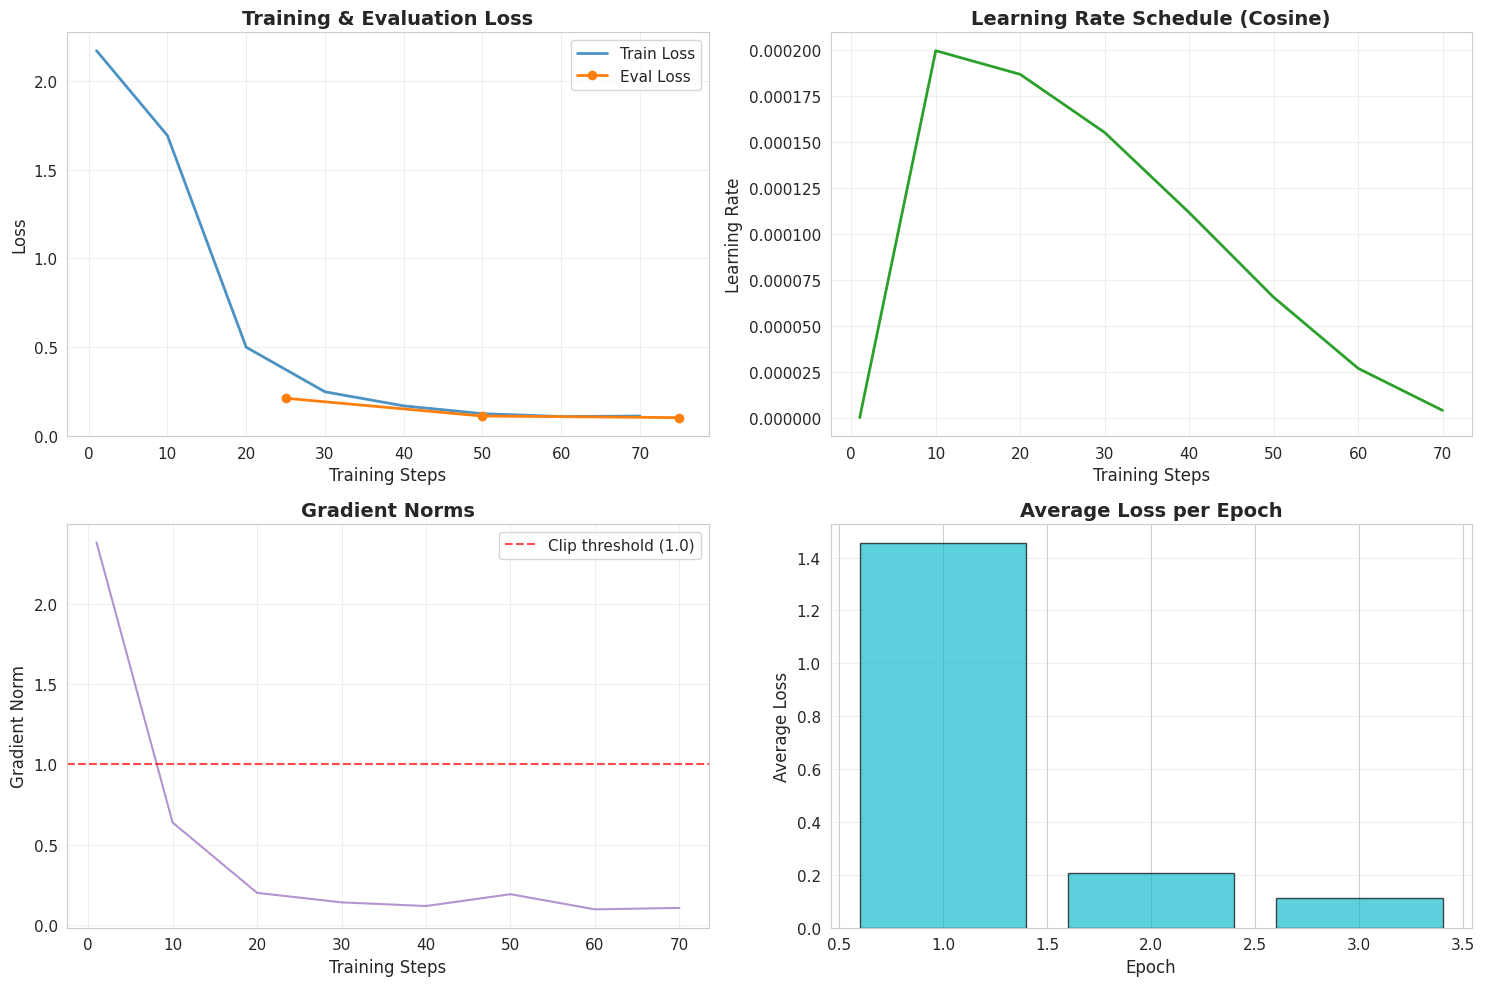

✅ Training curves saved to: /root/SLM_Legal_AI/reports/training_curves.png


In [22]:
# ============================================================================
# CELL 16: Visualize Training Curves
# ============================================================================
print("\n📊 VISUALIZING TRAINING CURVES")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Training & Evaluation Loss
ax1 = axes[0, 0]
ax1.plot(metrics_callback.steps, metrics_callback.training_loss,
         label='Train Loss', linewidth=2, color='#1f77b4', alpha=0.8)

if metrics_callback.eval_loss and metrics_callback.eval_steps:
    ax1.plot(metrics_callback.eval_steps, metrics_callback.eval_loss,
             label='Eval Loss', linewidth=2, color='#ff7f0e', marker='o', markersize=6)

# Add loss spike markers
if metrics_callback.loss_spikes:
    spike_steps = [s["step"] for s in metrics_callback.loss_spikes]
    spike_losses = [s["loss"] for s in metrics_callback.loss_spikes]
    ax1.scatter(spike_steps, spike_losses, color='red', s=100, marker='x',
                label=f'Loss Spikes ({len(spike_steps)})', zorder=5)

ax1.set_xlabel('Training Steps', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training & Evaluation Loss', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Plot 2: Learning Rate Schedule
ax2 = axes[0, 1]
if metrics_callback.learning_rates:
    ax2.plot(metrics_callback.steps[:len(metrics_callback.learning_rates)],
             metrics_callback.learning_rates, linewidth=2, color='#2ca02c')
ax2.set_xlabel('Training Steps', fontsize=12)
ax2.set_ylabel('Learning Rate', fontsize=12)
ax2.set_title('Learning Rate Schedule (Cosine)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Plot 3: Gradient Norms
ax3 = axes[1, 0]
if metrics_callback.gradient_norms:
    ax3.plot(metrics_callback.steps[:len(metrics_callback.gradient_norms)],
             metrics_callback.gradient_norms, linewidth=1.5, color='#9467bd', alpha=0.7)
    ax3.axhline(y=MAX_GRAD_NORM, color='red', linestyle='--',
                label=f'Clip threshold ({MAX_GRAD_NORM})', alpha=0.7)
    ax3.legend()
ax3.set_xlabel('Training Steps', fontsize=12)
ax3.set_ylabel('Gradient Norm', fontsize=12)
ax3.set_title('Gradient Norms', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Plot 4: Loss by Epoch (Smoothed)
ax4 = axes[1, 1]
if metrics_callback.epochs and metrics_callback.training_loss:
    epochs_arr = np.array(metrics_callback.epochs)
    loss_arr = np.array(metrics_callback.training_loss)

    # Group by epoch
    unique_epochs = np.unique(np.floor(epochs_arr))
    epoch_losses = []
    for epoch in unique_epochs:
        mask = np.floor(epochs_arr) == epoch
        epoch_losses.append(np.mean(loss_arr[mask]))

    ax4.bar(unique_epochs + 1, epoch_losses, color='#17becf', alpha=0.7, edgecolor='black')
    ax4.set_xlabel('Epoch', fontsize=12)
    ax4.set_ylabel('Average Loss', fontsize=12)
    ax4.set_title('Average Loss per Epoch', fontsize=14, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
curves_path = f"{GDRIVE_BASE}/reports/training_curves.png"
plt.savefig(curves_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Training curves saved to: {curves_path}")

## 17. Save Model to Google Drive

In [23]:
# ============================================================================
# CELL 17: Save Model to Google Drive
# ============================================================================
print("\n💾 SAVING MODEL TO GOOGLE DRIVE")
print("=" * 60)

# Create versioned paths
version_dir = f"{GDRIVE_BASE}/models/versions/{MODEL_VERSION}"
os.makedirs(version_dir, exist_ok=True)

# Save LoRA adapters
adapter_path = f"{version_dir}/{MODEL_SAVE_NAME}_lora"
model.save_pretrained(adapter_path)
tokenizer.save_pretrained(adapter_path)
print(f"✅ LoRA adapters saved to: {adapter_path}")

# Save merged model (16-bit)
merged_path = f"{version_dir}/{MODEL_SAVE_NAME}_merged"
model.save_pretrained_merged(merged_path, tokenizer, save_method="merged_16bit")
print(f"✅ Merged model (16-bit) saved to: {merged_path}")

# Save training metrics to CSV
metrics_df = pd.DataFrame({
    'step': metrics_callback.steps,
    'epoch': metrics_callback.epochs[:len(metrics_callback.steps)],
    'train_loss': metrics_callback.training_loss,
    'learning_rate': metrics_callback.learning_rates[:len(metrics_callback.steps)] if metrics_callback.learning_rates else [None] * len(metrics_callback.steps),
})
metrics_csv_path = f"{GDRIVE_BASE}/reports/training_metrics_{MODEL_VERSION}.csv"
metrics_df.to_csv(metrics_csv_path, index=False)
print(f"✅ Metrics saved to: {metrics_csv_path}")

# Save comprehensive training summary
training_summary = {
    "model_version": MODEL_VERSION,
    "pipeline_version": PIPELINE_VERSION,
    "model": MODEL_NAME,
    "training_timestamp": datetime.now().isoformat(),
    "training_duration_minutes": round(training_duration / 60, 2),
    "final_train_loss": float(metrics_callback.training_loss[-1]),
    "final_eval_loss": float(metrics_callback.eval_loss[-1]) if metrics_callback.eval_loss else None,
    "best_eval_loss": float(min(metrics_callback.eval_loss)) if metrics_callback.eval_loss else None,
    "total_steps": len(metrics_callback.steps),
    "train_samples": len(train_dataset),
    "eval_samples": len(eval_dataset),
    "test_samples": len(test_dataset),
    "data_hash": data_hash,
    "config": CONFIG,
    "issues_detected": metrics_callback.detect_issues(),
    "loss_spikes": len(metrics_callback.loss_spikes),
    "gradient_explosions": len(metrics_callback.gradient_explosions),
}

summary_path = f"{GDRIVE_BASE}/reports/training_summary_{MODEL_VERSION}.json"
with open(summary_path, "w") as f:
    json.dump(training_summary, f, indent=2)
print(f"✅ Training summary saved to: {summary_path}")

# Create symlink to latest version
latest_path = f"{GDRIVE_BASE}/models/latest"
if os.path.exists(latest_path):
    if os.path.islink(latest_path):
        os.unlink(latest_path)
    else:
        shutil.rmtree(latest_path)
os.symlink(version_dir, latest_path)
print(f"✅ Latest symlink created: {latest_path} -> {version_dir}")

print("\n✅ All model artifacts saved to Google Drive!")


💾 SAVING MODEL TO GOOGLE DRIVE
✅ LoRA adapters saved to: /root/SLM_Legal_AI/models/versions/v1.0.0/qwen3-8b-Q4-sri-lankan-legal_lora


config.json:   0%|          | 0.00/754 [00:00<?, ?B/s]

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Checking cache directory for required files...
Cache check failed: model-00001-of-00004.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


...

model-00004-of-00004.safetensors:   0%|          | 0.00/1.58G [00:00<?, ?B/s]

Unsloth: Preparing safetensor model files: 100%|█████████████████████████████████| 4/4 [01:09<00:00, 17.49s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|███████████████████████████████████████| 4/4 [00:54<00:00, 13.73s/it]


Unsloth: Merge process complete. Saved to `/root/SLM_Legal_AI/models/versions/v1.0.0/qwen3-8b-Q4-sri-lankan-legal_merged`
✅ Merged model (16-bit) saved to: /root/SLM_Legal_AI/models/versions/v1.0.0/qwen3-8b-Q4-sri-lankan-legal_merged
✅ Metrics saved to: /root/SLM_Legal_AI/reports/training_metrics_v1.0.0.csv
✅ Training summary saved to: /root/SLM_Legal_AI/reports/training_summary_v1.0.0.json
✅ Latest symlink created: /root/SLM_Legal_AI/models/latest -> /root/SLM_Legal_AI/models/versions/v1.0.0

✅ All model artifacts saved to Google Drive!


## 18. Test Inference (Quick Check)

In [24]:
# ============================================================================
# CELL 18: Test Inference (Quick Check)
# ============================================================================
print("\n🧪 TESTING INFERENCE")
print("=" * 60)

# Switch to inference mode
FastLanguageModel.for_inference(model)

# Test case: Pregnancy termination (common labour law issue)
test_instruction = """An employer terminated a female employee soon after she announced her pregnancy.
The employee had been working for the company for 3 years with good performance reviews.
What legal protections apply under Sri Lankan labour law?"""

test_context = ""  # In production, this would be filled via RAG

# Build messages
messages = [
    {"role": "system", "content": SYSTEM_PROMPT},
    {"role": "user", "content": make_user_prompt(test_instruction, test_context)},
]

# Apply chat template
prompt = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=False
)

# Tokenize
inputs = tokenizer([prompt], return_tensors="pt").to(model.device)

print("🤔 Generating response...")
inference_start = time.time()

# Generate
generated = model.generate(
    **inputs,
    max_new_tokens=1200,
    temperature=0.3,
    top_p=0.9,
    do_sample=True,
    pad_token_id=tokenizer.eos_token_id,
)

inference_time = time.time() - inference_start

# Decode
output = tokenizer.decode(
    generated[0][inputs["input_ids"].shape[1]:],
    skip_special_tokens=True
)

print("\n" + "=" * 60)
print("📝 RAW OUTPUT:")
print("=" * 60)
print(output[:1500] if len(output) > 1500 else output)
print("\n" + "=" * 60)

# Try parsing JSON
def clean_json_output(text: str) -> str:
    """Clean model output to extract JSON."""
    text = text.strip()

    # Remove markdown code blocks
    if text.startswith("```json"):
        text = text.split("```json", 1)[1]
        if "```" in text:
            text = text.split("```")[0]
    elif text.startswith("```"):
        text = text.split("```", 1)[1]
        if "```" in text:
            text = text.split("```")[0]

    # Remove thinking tags if present
    if "<think>" in text:
        text = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL)

    return text.strip()

try:
    clean_output = clean_json_output(output)
    parsed_obj = json.loads(clean_output)

    print("✅ JSON parsed successfully!")
    print(f"\n📋 Parsed Output Summary:")
    print(f"   scope_category: {parsed_obj.get('scope_category')}")
    print(f"   out_of_scope: {parsed_obj.get('out_of_scope')}")
    print(f"   confidence: {parsed_obj.get('confidence')}")
    print(f"   violations: {len(parsed_obj.get('primary_violations', []))}")
    print(f"   cases: {len(parsed_obj.get('supporting_cases', []))}")
    print(f"   ⏱️ Inference time: {inference_time:.2f}s")

    if parsed_obj.get('summary'):
        print(f"\n📝 Primary Issue: {parsed_obj['summary'].get('primary_issue', 'N/A')}")

except json.JSONDecodeError as e:
    print(f"\n❌ JSON parse failed: {e}")
    print(f"\n💡 Troubleshooting:")
    print("   1. Model may need more training epochs")
    print("   2. Check if system prompt is being followed")
    print("   3. Verify training data quality")
    print("   4. Check for <think> tags in output")

# Check for thinking tags
if "<think>" in output:
    print("\n⚠️ WARNING: <think> tags detected in output!")
    print("   The model is including reasoning chains.")
    print("   This may affect JSON parsing reliability.")
else:
    print("\n✅ No <think> tags detected - clean output!")


🧪 TESTING INFERENCE
🤔 Generating response...

📝 RAW OUTPUT:
{"out_of_scope": false, "scope_category": "labour_employment_law", "summary": {"primary_issue": "Discrimination due to pregnancy", "violation_count": 1, "acts_count": 1, "cases_count": 0}, "primary_violations": [{"violation_type": "Pregnancy Discrimination", "act_name": "Termination of Employment of Workmen (Special Provisions) Act No. 45 of 1971", "act_year": 1971, "act_section": "Section 31B(1)", "violation_details": "The act prohibits the termination of a woman's employment due to pregnancy or the likelihood of pregnancy. Employers are legally bound to provide a safe workplace, and such discrimination is considered a violation of the law."}], "supporting_cases": [], "legal_reasoning": "The specific act provides clear protections against pregnancy-related discrimination. The employer's actions of terminating a female employee shortly after her pregnancy announcement likely fall under the scope of this act. There is no need 

## 19. Export GGUF Models

In [34]:
# ============================================================================
# CELL 19: Export GGUF Models
# ============================================================================
print("\n📦 EXPORTING GGUF MODELS")
print("=" * 60)

gguf_exports = {}

# Q4_K_M - Recommended for production
print("💾 Saving Q4_K_M quantized GGUF (recommended for deployment)...")
q4_path = f"{version_dir}/{MODEL_SAVE_NAME}_gguf_q4"
try:
    model.save_pretrained_gguf(q4_path, tokenizer, quantization_method="q4_k_m")
    gguf_exports["q4_k_m"] = q4_path
    print(f"✅ Q4_K_M saved to: {q4_path}")
except Exception as e:
    print(f"❌ Q4_K_M export failed: {e}")

# Q8_0 - Higher quality
print("\n💾 Saving Q8_0 quantized GGUF (higher quality)...")
q8_path = f"{version_dir}/{MODEL_SAVE_NAME}_gguf_q8"
try:
    model.save_pretrained_gguf(q8_path, tokenizer, quantization_method="q8_0")
    gguf_exports["q8_0"] = q8_path
    print(f"✅ Q8_0 saved to: {q8_path}")
except Exception as e:
    print(f"❌ Q8_0 export failed: {e}")

# F16 - Full precision
print("\n💾 Saving F16 full precision GGUF...")
f16_path = f"{version_dir}/{MODEL_SAVE_NAME}_gguf_f16"
try:
    model.save_pretrained_gguf(f16_path, tokenizer, quantization_method="f16")
    gguf_exports["f16"] = f16_path
    print(f"✅ F16 saved to: {f16_path}")
except Exception as e:
    print(f"❌ F16 export failed: {e}")

print("\n" + "=" * 60)
print("📦 GGUF EXPORT SUMMARY")
print("=" * 60)
print(f"Q4_K_M: ~2.5GB - Fast inference, good quality (RECOMMENDED)")
print(f"Q8_0:   ~4.0GB - Slower, better quality")
print(f"F16:    ~8.0GB - Slowest, best quality")
print("\n💡 Usage Recommendations:")
print("   • Production API: Q4_K_M with llama.cpp server")
print("   • Local testing: Q4_K_M with Ollama")
print("   • Quality testing: Q8_0 or F16")


📦 EXPORTING GGUF MODELS
💾 Saving Q4_K_M quantized GGUF (recommended for deployment)...
Unsloth: Merging model weights to 16-bit format...
Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Checking cache directory for required files...
Cache check failed: model-00001-of-00004.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|                                         | 0/4 [00:00<?, ?it/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.88G [00:00<?, ?B/s]

...

model-00004-of-00004.safetensors:   0%|          | 0.00/1.09G [00:00<?, ?B/s]

Unsloth: Preparing safetensor model files: 100%|█████████████████████████████████| 4/4 [01:26<00:00, 21.53s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|███████████████████████████████████████| 4/4 [00:31<00:00,  7.85s/it]


Unsloth: Merge process complete. Saved to `/root/SLM_Legal_AI/models/versions/v1.0.0/qwen3-4b-sri-lankan-legal_gguf_f16`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF bf16 might take 3 minutes.
\        /    [2] Converting GGUF bf16 to ['f16'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Updating system package directories
Unsloth: Missing packages: libcurl4-openssl-dev
Unsloth: Will attempt to install missing system packages.
Unsloth: Installing packages: libcurl4-openssl-dev
❌ F16 export failed: Unsloth: GGUF conversion failed: raw_input was called, but this frontend does not support input requests.

📦 GGUF EXPORT SUMMARY
Q4_K_M: ~2.5GB - Fast inference, good quality (RECOMMENDED)
Q8_0:   ~4.0GB - Slower, better q

## 20. Comprehensive Error Analysis

In [25]:
# ============================================================================
# CELL 20: Comprehensive Error Analysis
# ============================================================================
print("\n🔍 COMPREHENSIVE ERROR ANALYSIS")
print("=" * 60)

@dataclass
class EvaluationResult:
    """Structured evaluation result for a single sample."""
    sample_idx: int
    instruction: str
    scope_category: str
    ground_truth: dict
    raw_output: str
    parsed_output: Optional[dict]
    inference_time: float

    # Error flags
    is_valid_json: bool
    has_think_tags: bool

    # Error details
    json_error: Optional[str] = None
    schema_errors: List[str] = None
    scope_mismatch: bool = False
    confidence_error: bool = False

    def __post_init__(self):
        if self.schema_errors is None:
            self.schema_errors = []

def evaluate_single_sample(sample_row: dict, idx: int) -> EvaluationResult:
    """Evaluate a single test sample with comprehensive error tracking."""

    instruction = sample_row.get("instruction", "")
    retrieved_context = sample_row.get("retrieved_context", "")
    ground_truth = sample_row.get("output", {})
    scope_category = ground_truth.get("scope_category", "unknown")

    # Build messages
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": make_user_prompt(instruction, retrieved_context)},
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False
    )

    inputs = tokenizer([prompt], return_tensors="pt").to(model.device)

    # Generate
    start = time.time()
    with torch.no_grad():
        generated = model.generate(
            **inputs,
            max_new_tokens=1200,
            temperature=0.3,
            top_p=0.9,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )
    inference_time = time.time() - start

    # Decode
    raw_output = tokenizer.decode(
        generated[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    )

    # Initialize result
    result = EvaluationResult(
        sample_idx=idx,
        instruction=instruction[:200],
        scope_category=scope_category,
        ground_truth=ground_truth,
        raw_output=raw_output,
        parsed_output=None,
        inference_time=inference_time,
        is_valid_json=False,
        has_think_tags="<think>" in raw_output,
    )

    # Try parsing JSON
    try:
        clean_output = clean_json_output(raw_output)
        parsed = json.loads(clean_output)
        result.parsed_output = parsed
        result.is_valid_json = True

        # Schema validation
        for key in REQUIRED_OUTPUT_KEYS:
            if key not in parsed:
                result.schema_errors.append(f"missing_{key}")

        # Scope mismatch detection
        pred_scope = parsed.get("scope_category", "")
        gt_scope = ground_truth.get("scope_category", "")
        if pred_scope != gt_scope:
            result.scope_mismatch = True

        # Confidence validation
        conf = parsed.get("confidence", 0)
        if not isinstance(conf, (int, float)) or conf < 0 or conf > 1:
            result.confidence_error = True

    except json.JSONDecodeError as e:
        result.json_error = str(e)

    return result

# Run evaluation on test set
print(f"Evaluating {min(MAX_TEST_SAMPLES, len(original_test_rows))} test samples...")
evaluation_results = []

for i, row in enumerate(original_test_rows[:MAX_TEST_SAMPLES]):
    result = evaluate_single_sample(row, i)
    evaluation_results.append(result)

    if (i + 1) % 20 == 0:
        print(f"   Processed {i+1}/{min(MAX_TEST_SAMPLES, len(original_test_rows))} samples...")

# Analyze errors
error_analysis = {
    "json_parse_errors": [],
    "schema_violations": [],
    "scope_misclassifications": [],
    "think_tag_occurrences": [],
    "confidence_errors": [],
}

for result in evaluation_results:
    if result.json_error:
        error_analysis["json_parse_errors"].append({
            "idx": result.sample_idx,
            "error": result.json_error,
            "category": result.scope_category,
            "output_preview": result.raw_output[:200],
        })

    if result.schema_errors:
        error_analysis["schema_violations"].append({
            "idx": result.sample_idx,
            "errors": result.schema_errors,
            "category": result.scope_category,
        })

    if result.scope_mismatch:
        error_analysis["scope_misclassifications"].append({
            "idx": result.sample_idx,
            "expected": result.scope_category,
            "predicted": result.parsed_output.get("scope_category", "N/A") if result.parsed_output else "N/A",
        })

    if result.has_think_tags:
        error_analysis["think_tag_occurrences"].append({
            "idx": result.sample_idx,
            "category": result.scope_category,
        })

    if result.confidence_error:
        error_analysis["confidence_errors"].append({
            "idx": result.sample_idx,
            "category": result.scope_category,
        })

# Print error summary
print("\n" + "=" * 60)
print("📊 ERROR ANALYSIS SUMMARY")
print("=" * 60)

total_samples = len(evaluation_results)
valid_json = sum(1 for r in evaluation_results if r.is_valid_json)

print(f"\n📋 Overall Statistics:")
print(f"   Total samples: {total_samples}")
print(f"   Valid JSON: {valid_json} ({valid_json/total_samples*100:.1f}%)")
print(f"   JSON Parse Errors: {len(error_analysis['json_parse_errors'])}")
print(f"   Schema Violations: {len(error_analysis['schema_violations'])}")
print(f"   Scope Misclassifications: {len(error_analysis['scope_misclassifications'])}")
print(f"   Think Tag Occurrences: {len(error_analysis['think_tag_occurrences'])}")
print(f"   Confidence Errors: {len(error_analysis['confidence_errors'])}")

# Actionable recommendations
print(f"\n💡 ACTIONABLE RECOMMENDATIONS:")

if error_analysis["json_parse_errors"]:
    print(f"\n   📌 JSON Parse Errors ({len(error_analysis['json_parse_errors'])} occurrences):")
    print("      • Check training data for malformed JSON examples")
    print("      • Increase training epochs to improve JSON structure learning")
    print("      • Verify system prompt explicitly requests JSON-only output")

if error_analysis["schema_violations"]:
    missing_fields = defaultdict(int)
    for err in error_analysis["schema_violations"]:
        for field in err["errors"]:
            missing_fields[field] += 1
    print(f"\n   📌 Schema Violations ({len(error_analysis['schema_violations'])} samples):")
    print("      Most commonly missing fields:")
    for field, count in sorted(missing_fields.items(), key=lambda x: -x[1])[:5]:
        print(f"         • {field}: {count} occurrences")

if error_analysis["scope_misclassifications"]:
    print(f"\n   📌 Scope Misclassifications ({len(error_analysis['scope_misclassifications'])} samples):")
    print("      • Review training examples for ambiguous cases")
    print("      • Consider adding more examples for confused categories")

if error_analysis["think_tag_occurrences"]:
    print(f"\n   📌 Think Tag Issues ({len(error_analysis['think_tag_occurrences'])} samples):")
    print("      • Ensure /no_think is in system prompt")
    print("      • Verify enable_thinking=False in chat template")

# Save error analysis
error_analysis_path = f"{GDRIVE_BASE}/errors/error_analysis_{MODEL_VERSION}.json"
with open(error_analysis_path, "w") as f:
    json.dump(error_analysis, f, indent=2)
print(f"\n✅ Error analysis saved to: {error_analysis_path}")


🔍 COMPREHENSIVE ERROR ANALYSIS
Evaluating 50 test samples...
   Processed 20/50 samples...
   Processed 40/50 samples...

📊 ERROR ANALYSIS SUMMARY

📋 Overall Statistics:
   Total samples: 50
   Valid JSON: 49 (98.0%)
   JSON Parse Errors: 1
   Schema Violations: 15
   Scope Misclassifications: 1
   Think Tag Occurrences: 0
   Confidence Errors: 0

💡 ACTIONABLE RECOMMENDATIONS:

   📌 JSON Parse Errors (1 occurrences):
      • Check training data for malformed JSON examples
      • Increase training epochs to improve JSON structure learning
      • Verify system prompt explicitly requests JSON-only output

   📌 Schema Violations (15 samples):
      Most commonly missing fields:
         • missing_confidence: 13 occurrences
         • missing_limits: 2 occurrences

   📌 Scope Misclassifications (1 samples):
      • Review training examples for ambiguous cases
      • Consider adding more examples for confused categories

✅ Error analysis saved to: /root/SLM_Legal_AI/errors/error_analysis

## 21. Per-Category Performance Evaluation


📊 PER-CATEGORY PERFORMANCE EVALUATION

📋 Performance by Category:
------------------------------------------------------------------------------------------
Category                   Samples   JSON Valid    Scope Acc   Avg Time   Confidence
------------------------------------------------------------------------------------------
environmental_law                1       100.0%         0.0%     10.10s        0.90
labour_employment_law           48        97.9%        97.9%     38.08s        0.89
land_land_registration_law        1       100.0%       100.0%      8.50s        0.90
------------------------------------------------------------------------------------------

🏆 Best performing: environmental_law (100.0% JSON validity)
⚠️ Needs improvement: labour_employment_law (97.9% JSON validity)


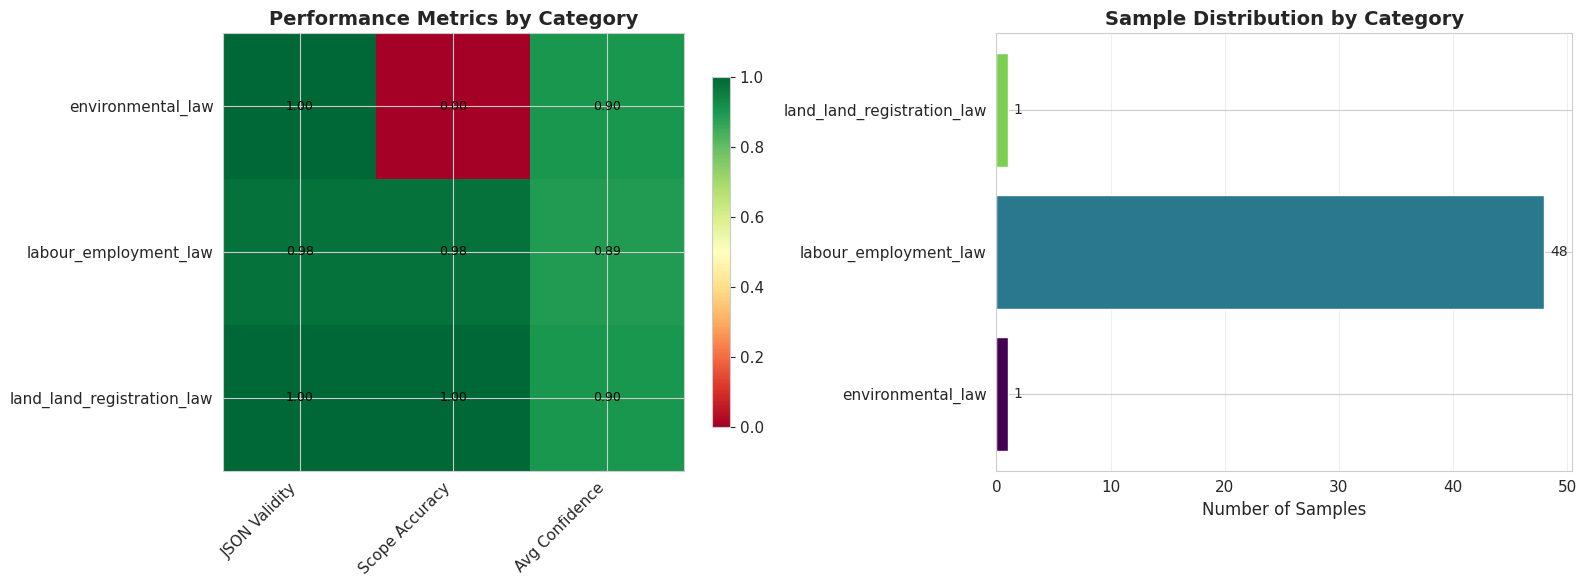


✅ Category performance chart saved to: /root/SLM_Legal_AI/reports/category_performance.png
✅ Category metrics saved to: /root/SLM_Legal_AI/reports/category_metrics_v1.0.0.json


In [28]:
# ============================================================================
# CELL 21: Per-Category Performance Evaluation
# ============================================================================
print("\n📊 PER-CATEGORY PERFORMANCE EVALUATION")
print("=" * 60)

# Group results by category
category_results = defaultdict(list)
for result in evaluation_results:
    category_results[result.scope_category].append(result)

# Calculate metrics per category
category_metrics = {}

for category, results in category_results.items():
    n = len(results)
    if n == 0:
        continue

    valid_json_count = sum(1 for r in results if r.is_valid_json)
    scope_correct = sum(1 for r in results if not r.scope_mismatch and r.is_valid_json)
    avg_inference_time = np.mean([r.inference_time for r in results])

    # Get average confidence for valid outputs
    confidences = [r.parsed_output.get("confidence", 0)
                   for r in results if r.parsed_output and isinstance(r.parsed_output.get("confidence"), (int, float))]
    avg_confidence = np.mean(confidences) if confidences else 0

    category_metrics[category] = {
        "sample_count": n,
        "json_validity_rate": valid_json_count / n,
        "scope_accuracy": scope_correct / n if valid_json_count > 0 else 0,
        "avg_inference_time": avg_inference_time,
        "avg_confidence": avg_confidence,
        "schema_error_rate": sum(1 for r in results if r.schema_errors) / n,
        "think_tag_rate": sum(1 for r in results if r.has_think_tags) / n,
    }

# Print per-category metrics
print(f"\n📋 Performance by Category:")
print("-" * 90)
print(f"{'Category':<25} {'Samples':>8} {'JSON Valid':>12} {'Scope Acc':>12} {'Avg Time':>10} {'Confidence':>12}")
print("-" * 90)

for category in sorted(category_metrics.keys()):
    m = category_metrics[category]
    print(f"{category:<25} {m['sample_count']:>8} {m['json_validity_rate']*100:>11.1f}% {m['scope_accuracy']*100:>11.1f}% {m['avg_inference_time']:>9.2f}s {m['avg_confidence']:>11.2f}")

print("-" * 90)

# Identify best and worst categories
if category_metrics:
    best_cat = max(category_metrics.items(), key=lambda x: x[1]["json_validity_rate"])
    worst_cat = min(category_metrics.items(), key=lambda x: x[1]["json_validity_rate"])

    print(f"\n🏆 Best performing: {best_cat[0]} ({best_cat[1]['json_validity_rate']*100:.1f}% JSON validity)")
    print(f"⚠️ Needs improvement: {worst_cat[0]} ({worst_cat[1]['json_validity_rate']*100:.1f}% JSON validity)")

# Create heatmap visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap 1: Key metrics per category
categories = sorted(category_metrics.keys())
metrics_names = ["json_validity_rate", "scope_accuracy", "avg_confidence"]
heatmap_data = np.array([[category_metrics[cat][m] for m in metrics_names] for cat in categories])

ax1 = axes[0]
im1 = ax1.imshow(heatmap_data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax1.set_xticks(range(len(metrics_names)))
ax1.set_xticklabels(['JSON Validity', 'Scope Accuracy', 'Avg Confidence'], rotation=45, ha='right')
ax1.set_yticks(range(len(categories)))
ax1.set_yticklabels(categories)
ax1.set_title('Performance Metrics by Category', fontsize=14, fontweight='bold')

# Add text annotations
for i in range(len(categories)):
    for j in range(len(metrics_names)):
        text = ax1.text(j, i, f'{heatmap_data[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=9)

plt.colorbar(im1, ax=ax1, shrink=0.8)

# Bar chart: Sample distribution
ax2 = axes[1]
sample_counts = [category_metrics[cat]["sample_count"] for cat in categories]
colors = plt.cm.viridis(np.linspace(0, 0.8, len(categories)))
bars = ax2.barh(categories, sample_counts, color=colors)
ax2.set_xlabel('Number of Samples', fontsize=12)
ax2.set_title('Sample Distribution by Category', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Add count labels
for bar, count in zip(bars, sample_counts):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             str(count), va='center', fontsize=10)

plt.tight_layout()
category_metrics_path = f"{GDRIVE_BASE}/reports/category_performance.png"
plt.savefig(category_metrics_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Category performance chart saved to: {category_metrics_path}")

# Save category metrics
category_metrics_json_path = f"{GDRIVE_BASE}/reports/category_metrics_{MODEL_VERSION}.json"
with open(category_metrics_json_path, "w") as f:
    json.dump(category_metrics, f, indent=2)
print(f"✅ Category metrics saved to: {category_metrics_json_path}")

## 22. Quality Metrics with Confidence Intervals


📏 CALCULATING QUALITY METRICS WITH CONFIDENCE INTERVALS
Loading semantic similarity model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Calculating quality metrics...

📊 QUALITY METRICS WITH 95% CONFIDENCE INTERVALS

Metric                          Mean    95% CI Lower    95% CI Upper        N
---------------------------------------------------------------------------
rouge1                         0.468           0.445           0.489       49
rouge2                         0.201           0.182           0.220       49
rougeL                         0.261           0.249           0.275       49
semantic_similarity            0.740           0.722           0.758       49
---------------------------------------------------------------------------

📈 Quality Assessment:
   ⚠️ Good - Reasonable semantic alignment


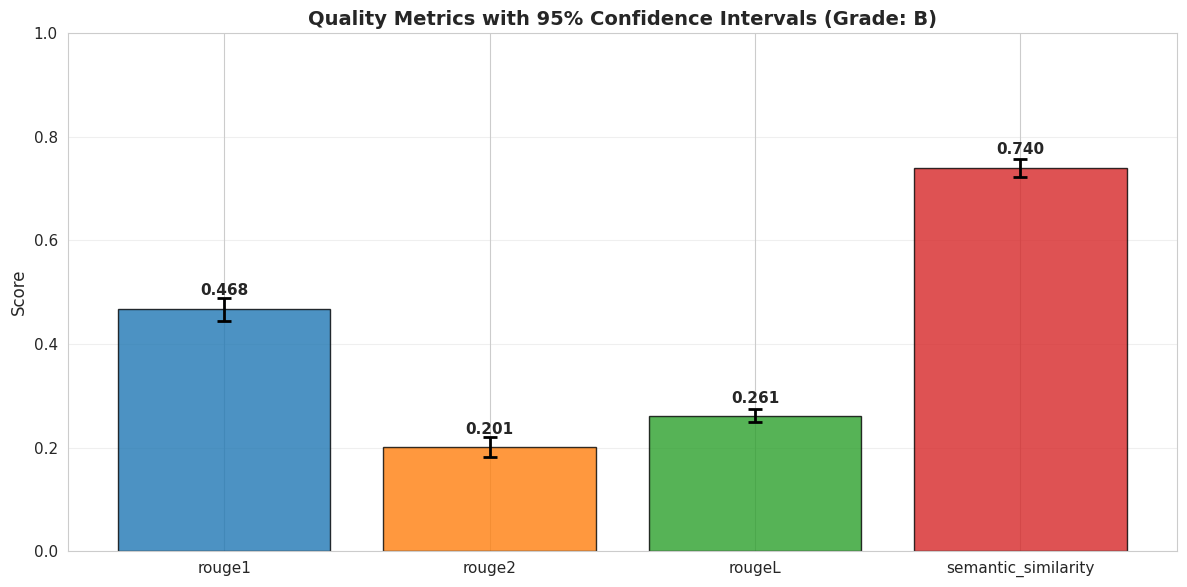


✅ Quality metrics chart saved to: /root/SLM_Legal_AI/reports/quality_metrics.png
✅ Quality metrics saved to: /root/SLM_Legal_AI/reports/quality_metrics_v1.0.0.json


In [27]:
# ============================================================================
# CELL 22: Quality Metrics with Confidence Intervals
# ============================================================================
print("\n📏 CALCULATING QUALITY METRICS WITH CONFIDENCE INTERVALS")
print("=" * 60)

# Install dependencies if needed
try:
    from rouge_score import rouge_scorer
    from sentence_transformers import SentenceTransformer, util
except ImportError:
    print("Installing metrics dependencies...")
    !pip install -q rouge-score sentence-transformers
    from rouge_score import rouge_scorer
    from sentence_transformers import SentenceTransformer, util

def bootstrap_ci(data: List[float], n_iterations: int = BOOTSTRAP_ITERATIONS,
                 confidence: float = CONFIDENCE_LEVEL) -> Tuple[float, float, float]:
    """Calculate bootstrap confidence interval."""
    if len(data) < 2:
        return np.mean(data), np.mean(data), np.mean(data)

    bootstrapped_means = []
    for _ in range(n_iterations):
        sample = np.random.choice(data, size=len(data), replace=True)
        bootstrapped_means.append(np.mean(sample))

    lower = np.percentile(bootstrapped_means, (1 - confidence) / 2 * 100)
    upper = np.percentile(bootstrapped_means, (1 + confidence) / 2 * 100)
    mean = np.mean(data)

    return mean, lower, upper

# Load sentence transformer for semantic similarity
print("Loading semantic similarity model...")
sem_model = SentenceTransformer('all-MiniLM-L6-v2')

# Initialize ROUGE scorer
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

# Calculate metrics for valid samples
rouge1_scores = []
rouge2_scores = []
rougeL_scores = []
semantic_similarities = []

print("Calculating quality metrics...")
for result in evaluation_results:
    if not result.is_valid_json or not result.parsed_output:
        continue

    gt_reasoning = result.ground_truth.get("legal_reasoning", "")
    pred_reasoning = result.parsed_output.get("legal_reasoning", "")

    if gt_reasoning and pred_reasoning:
        # ROUGE scores
        scores = scorer.score(gt_reasoning, pred_reasoning)
        rouge1_scores.append(scores['rouge1'].fmeasure)
        rouge2_scores.append(scores['rouge2'].fmeasure)
        rougeL_scores.append(scores['rougeL'].fmeasure)

        # Semantic similarity
        try:
            gt_emb = sem_model.encode(gt_reasoning, convert_to_tensor=True)
            pred_emb = sem_model.encode(pred_reasoning, convert_to_tensor=True)
            similarity = util.pytorch_cos_sim(gt_emb, pred_emb).item()
            semantic_similarities.append(similarity)
        except:
            pass

# Calculate metrics with confidence intervals
quality_metrics = {}

if rouge1_scores:
    r1_mean, r1_lower, r1_upper = bootstrap_ci(rouge1_scores)
    r2_mean, r2_lower, r2_upper = bootstrap_ci(rouge2_scores)
    rL_mean, rL_lower, rL_upper = bootstrap_ci(rougeL_scores)

    quality_metrics["rouge1"] = {"mean": r1_mean, "ci_lower": r1_lower, "ci_upper": r1_upper, "n": len(rouge1_scores)}
    quality_metrics["rouge2"] = {"mean": r2_mean, "ci_lower": r2_lower, "ci_upper": r2_upper, "n": len(rouge2_scores)}
    quality_metrics["rougeL"] = {"mean": rL_mean, "ci_lower": rL_lower, "ci_upper": rL_upper, "n": len(rougeL_scores)}

if semantic_similarities:
    sem_mean, sem_lower, sem_upper = bootstrap_ci(semantic_similarities)
    quality_metrics["semantic_similarity"] = {"mean": sem_mean, "ci_lower": sem_lower, "ci_upper": sem_upper, "n": len(semantic_similarities)}

# Print results
print("\n" + "=" * 60)
print("📊 QUALITY METRICS WITH 95% CONFIDENCE INTERVALS")
print("=" * 60)

if quality_metrics:
    print(f"\n{'Metric':<25} {'Mean':>10} {'95% CI Lower':>15} {'95% CI Upper':>15} {'N':>8}")
    print("-" * 75)

    for metric_name, values in quality_metrics.items():
        print(f"{metric_name:<25} {values['mean']:>10.3f} {values['ci_lower']:>15.3f} {values['ci_upper']:>15.3f} {values['n']:>8}")

    print("-" * 75)

    # Quality assessment
    print("\n📈 Quality Assessment:")
    sem_score = quality_metrics.get("semantic_similarity", {}).get("mean", 0)
    if sem_score >= 0.75:
        print("   ✅ Excellent - High semantic alignment with ground truth")
        quality_grade = "A"
    elif sem_score >= 0.60:
        print("   ⚠️ Good - Reasonable semantic alignment")
        quality_grade = "B"
    elif sem_score >= 0.45:
        print("   ⚠️ Fair - Moderate alignment, room for improvement")
        quality_grade = "C"
    else:
        print("   ❌ Poor - Low semantic alignment, needs retraining")
        quality_grade = "D"
else:
    print("⚠️ Not enough valid samples for quality metrics")
    quality_grade = "N/A"

# Visualize with error bars
if quality_metrics:
    fig, ax = plt.subplots(figsize=(12, 6))

    metrics_names = list(quality_metrics.keys())
    means = [quality_metrics[m]["mean"] for m in metrics_names]
    ci_lower = [quality_metrics[m]["mean"] - quality_metrics[m]["ci_lower"] for m in metrics_names]
    ci_upper = [quality_metrics[m]["ci_upper"] - quality_metrics[m]["mean"] for m in metrics_names]

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'][:len(metrics_names)]

    bars = ax.bar(metrics_names, means, color=colors, alpha=0.8, edgecolor='black')
    ax.errorbar(metrics_names, means, yerr=[ci_lower, ci_upper],
                fmt='none', color='black', capsize=5, capthick=2, linewidth=2)

    ax.set_ylabel('Score', fontsize=12)
    ax.set_title(f'Quality Metrics with 95% Confidence Intervals (Grade: {quality_grade})',
                 fontsize=14, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)

    # Add value labels
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2., mean + 0.02,
                f'{mean:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.tight_layout()
    quality_metrics_path = f"{GDRIVE_BASE}/reports/quality_metrics.png"
    plt.savefig(quality_metrics_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n✅ Quality metrics chart saved to: {quality_metrics_path}")

# Save quality metrics
quality_metrics_json_path = f"{GDRIVE_BASE}/reports/quality_metrics_{MODEL_VERSION}.json"
with open(quality_metrics_json_path, "w") as f:
    json.dump(quality_metrics, f, indent=2)
print(f"✅ Quality metrics saved to: {quality_metrics_json_path}")

## 23. Inference Speed Test with Percentiles


⚡ INFERENCE SPEED TEST WITH PERCENTILES

⚡ INFERENCE SPEED STATISTICS

📊 Distribution Statistics:
   Samples: 50
   Mean: 36.93s ± 11.25s
   Min: 8.50s
   Max: 68.59s

📈 Percentiles (for SLA planning):
   P50 (Median): 34.22s
   P75: 43.44s
   P90: 51.33s
   P95: 57.26s
   P99: 65.32s

🚀 Throughput Estimates:
   Queries/minute: ~1.6
   Tokens/second: ~32.5

💡 SLA Recommendations:
   • For 95% of requests: Set timeout to 57.3s
   • For 99% of requests: Set timeout to 65.3s
   • Expected capacity: 2 requests/minute/instance


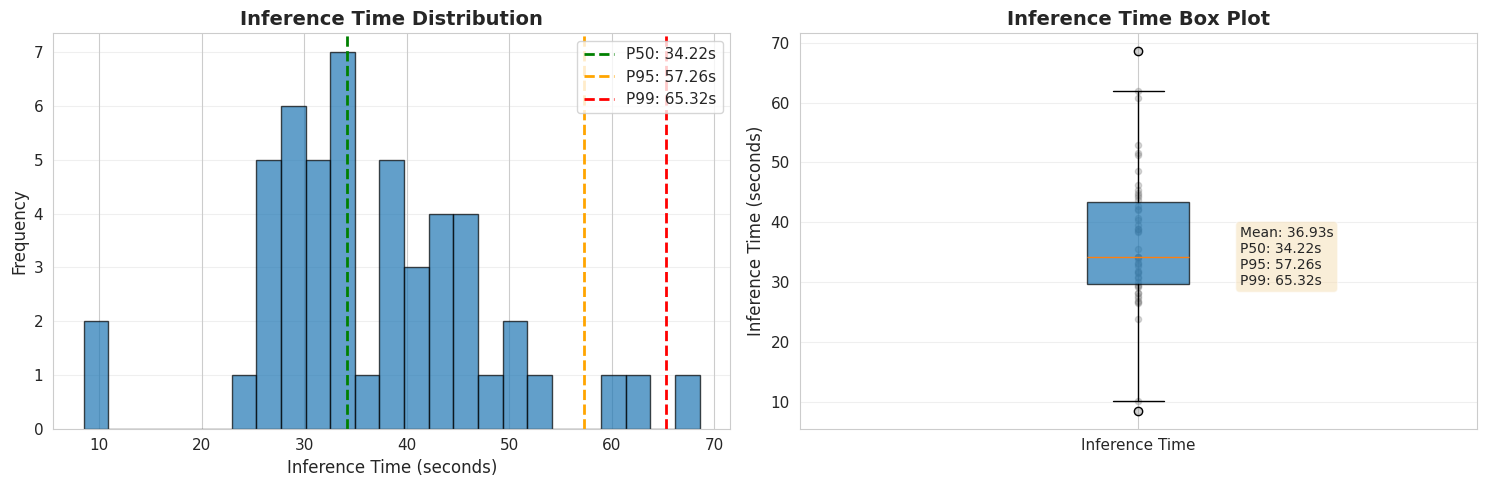


✅ Speed distribution chart saved to: /root/SLM_Legal_AI/reports/inference_speed.png
✅ Speed statistics saved to: /root/SLM_Legal_AI/reports/speed_stats_v1.0.0.json


In [29]:
# ============================================================================
# CELL 23: Inference Speed Test with Percentiles
# ============================================================================
print("\n⚡ INFERENCE SPEED TEST WITH PERCENTILES")
print("=" * 60)

# Collect inference times from evaluation results
inference_times = [r.inference_time for r in evaluation_results]

# If we need more samples for speed testing
if len(inference_times) < SPEED_TEST_SAMPLES:
    print(f"Running additional speed test on {SPEED_TEST_SAMPLES - len(inference_times)} samples...")
    for i, row in enumerate(original_test_rows[len(inference_times):SPEED_TEST_SAMPLES]):
        result = evaluate_single_sample(row, i + len(inference_times))
        inference_times.append(result.inference_time)
        if (i + 1) % 10 == 0:
            print(f"   Completed {i+1} additional samples...")

# Calculate statistics
speed_stats = {
    "mean": np.mean(inference_times),
    "std": np.std(inference_times),
    "min": np.min(inference_times),
    "max": np.max(inference_times),
    "p50": np.percentile(inference_times, 50),  # Median
    "p75": np.percentile(inference_times, 75),
    "p90": np.percentile(inference_times, 90),
    "p95": np.percentile(inference_times, 95),
    "p99": np.percentile(inference_times, 99),
    "throughput_per_minute": 60 / np.mean(inference_times),
    "tokens_per_second_estimate": 1200 / np.mean(inference_times),  # Assuming avg 1200 tokens
}

print("\n" + "=" * 60)
print("⚡ INFERENCE SPEED STATISTICS")
print("=" * 60)
print(f"\n📊 Distribution Statistics:")
print(f"   Samples: {len(inference_times)}")
print(f"   Mean: {speed_stats['mean']:.2f}s ± {speed_stats['std']:.2f}s")
print(f"   Min: {speed_stats['min']:.2f}s")
print(f"   Max: {speed_stats['max']:.2f}s")

print(f"\n📈 Percentiles (for SLA planning):")
print(f"   P50 (Median): {speed_stats['p50']:.2f}s")
print(f"   P75: {speed_stats['p75']:.2f}s")
print(f"   P90: {speed_stats['p90']:.2f}s")
print(f"   P95: {speed_stats['p95']:.2f}s")
print(f"   P99: {speed_stats['p99']:.2f}s")

print(f"\n🚀 Throughput Estimates:")
print(f"   Queries/minute: ~{speed_stats['throughput_per_minute']:.1f}")
print(f"   Tokens/second: ~{speed_stats['tokens_per_second_estimate']:.1f}")

# SLA recommendations
print(f"\n💡 SLA Recommendations:")
print(f"   • For 95% of requests: Set timeout to {speed_stats['p95']:.1f}s")
print(f"   • For 99% of requests: Set timeout to {speed_stats['p99']:.1f}s")
print(f"   • Expected capacity: {speed_stats['throughput_per_minute']:.0f} requests/minute/instance")

# Visualize speed distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram with percentile markers
ax1 = axes[0]
n, bins, patches = ax1.hist(inference_times, bins=25, color='#1f77b4',
                             edgecolor='black', alpha=0.7)

# Add percentile lines
percentiles = [('P50', speed_stats['p50'], 'green'),
               ('P95', speed_stats['p95'], 'orange'),
               ('P99', speed_stats['p99'], 'red')]

for name, value, color in percentiles:
    ax1.axvline(x=value, color=color, linestyle='--', linewidth=2,
                label=f'{name}: {value:.2f}s')

ax1.set_xlabel('Inference Time (seconds)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Inference Time Distribution', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(axis='y', alpha=0.3)

# Box plot
ax2 = axes[1]
bp = ax2.boxplot(inference_times, vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('#1f77b4')
bp['boxes'][0].set_alpha(0.7)

# Add individual points
ax2.scatter([1] * len(inference_times), inference_times, alpha=0.3, color='gray', s=20)

ax2.set_ylabel('Inference Time (seconds)', fontsize=12)
ax2.set_title('Inference Time Box Plot', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.set_xticklabels(['Inference Time'])

# Add stats annotation
stats_text = f"Mean: {speed_stats['mean']:.2f}s\nP50: {speed_stats['p50']:.2f}s\nP95: {speed_stats['p95']:.2f}s\nP99: {speed_stats['p99']:.2f}s"
ax2.text(1.15, np.median(inference_times), stats_text, fontsize=10,
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
speed_plot_path = f"{GDRIVE_BASE}/reports/inference_speed.png"
plt.savefig(speed_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Speed distribution chart saved to: {speed_plot_path}")

# Save speed stats
speed_stats_path = f"{GDRIVE_BASE}/reports/speed_stats_{MODEL_VERSION}.json"
with open(speed_stats_path, "w") as f:
    json.dump(speed_stats, f, indent=2)
print(f"✅ Speed statistics saved to: {speed_stats_path}")

## 24. Sample Response Comparison

In [33]:
# ============================================================================
# CELL 24: Sample Response Comparison
# ============================================================================
print("\n📋 SAMPLE RESPONSE COMPARISON")
print("=" * 60)

# Select diverse samples for comparison
# - One from best performing category
# - One from worst performing category
# - One random sample

comparison_samples = []

# Get one valid sample from different categories
categories_represented = set()
for result in evaluation_results:
    if result.is_valid_json and result.scope_category not in categories_represented:
        comparison_samples.append(result)
        categories_represented.add(result.scope_category)
    if len(comparison_samples) >= 4:
        break

# Add an error case if available
for result in evaluation_results:
    if not result.is_valid_json:
        comparison_samples.append(result)
        break

print(f"Comparing {len(comparison_samples)} samples across different categories:\n")

for idx, result in enumerate(comparison_samples, 1):
    print("=" * 80)
    print(f"📝 SAMPLE {idx}: {result.scope_category.upper()}")
    print("=" * 80)

    print(f"\n📄 Instruction (truncated):")
    print(f"   {result.instruction}...")

    print(f"\n🎯 Ground Truth:")
    gt_summary = result.ground_truth.get("summary", {})
    print(f"   Primary Issue: {gt_summary.get('primary_issue', 'N/A')}")
    print(f"   Violations: {gt_summary.get('violation_count', 'N/A')}")
    print(f"   Confidence: {result.ground_truth.get('confidence', 'N/A')}")

    if result.is_valid_json and result.parsed_output:
        print(f"\n🤖 Model Output:")
        pred_summary = result.parsed_output.get("summary", {})
        print(f"   Primary Issue: {pred_summary.get('primary_issue', 'N/A')}")
        print(f"   Violations: {pred_summary.get('violation_count', 'N/A')}")
        print(f"   Confidence: {result.parsed_output.get('confidence', 'N/A')}")

        print(f"\n✅ Status: Valid JSON")
        print(f"⏱️ Inference Time: {result.inference_time:.2f}s")

        if result.scope_mismatch:
            print(f"⚠️ Scope Mismatch: Expected '{result.scope_category}', Got '{result.parsed_output.get('scope_category')}'")
        else:
            print(f"✅ Scope Match: {result.scope_category}")

        # Compare legal reasoning (first 200 chars)
        gt_reasoning = result.ground_truth.get("legal_reasoning", "")[:200]
        pred_reasoning = result.parsed_output.get("legal_reasoning", "")[:200]

        if gt_reasoning and pred_reasoning:
            print(f"\n📚 Legal Reasoning Comparison:")
            print(f"   Ground Truth: {gt_reasoning}...")
            print(f"   Model Output: {pred_reasoning}...")
    else:
        print(f"\n❌ Status: Invalid JSON")
        print(f"   Error: {result.json_error}")
        print(f"   Raw Output Preview: {result.raw_output[:300]}...")

    print()

# Summary comparison table
print("\n" + "=" * 80)
print("📊 COMPARISON SUMMARY TABLE")
print("=" * 80)
print(f"{'#':<3} {'Category':<20} {'JSON Valid':<12} {'Scope Match':<12} {'Time':>8}")
print("-" * 60)

for idx, result in enumerate(comparison_samples, 1):
    json_valid = "✅ Yes" if result.is_valid_json else "❌ No"
    scope_match = "✅ Yes" if (result.is_valid_json and not result.scope_mismatch) else ("⚠️ No" if result.is_valid_json else "N/A")
    print(f"{idx:<3} {result.scope_category:<20} {json_valid:<12} {scope_match:<12} {result.inference_time:>7.2f}s")


📋 SAMPLE RESPONSE COMPARISON
Comparing 4 samples across different categories:

📝 SAMPLE 1: LABOUR_EMPLOYMENT_LAW

📄 Instruction (truncated):
   I was a Managing Director for seven years but recently resigned. My employer says I'm not a 'workman' for gratuity. Is this correct?...

🎯 Ground Truth:
   Primary Issue: Eligibility of a Managing Director to claim statutory gratuity as a 'workman'.
   Violations: 1
   Confidence: 1.0

🤖 Model Output:
   Primary Issue: Whether a Group Managing Director qualifies as a 'workman' for gratuity under the Payment of Gratuity Act No. 12 of 1983.
   Violations: 1
   Confidence: 0.85

✅ Status: Valid JSON
⏱️ Inference Time: 52.91s
✅ Scope Match: labour_employment_law

📚 Legal Reasoning Comparison:
   Ground Truth: Under Sri Lankan law, specifically the Payment of Gratuity Act No. 12 of 1983, the definition of a 'workman' is broad enough to include high-level executives. The landmark decision in Collettes Ltd. v...
   Model Output: The court in Collette

## 25. Model Comparison Framework

In [31]:
# ============================================================================
# CELL 25: Model Comparison Framework
# ============================================================================
print("\n🔄 MODEL COMPARISON FRAMEWORK")
print("=" * 60)

class ModelComparisonFramework:
    """Framework for comparing model versions and tracking improvements."""

    def __init__(self, base_path: str):
        self.base_path = base_path
        self.comparisons_path = f"{base_path}/reports/comparisons"
        self.history_file = f"{self.comparisons_path}/version_history.json"
        os.makedirs(self.comparisons_path, exist_ok=True)
        self.history = self._load_history()

    def _load_history(self) -> dict:
        """Load version history from disk."""
        if os.path.exists(self.history_file):
            with open(self.history_file, "r") as f:
                return json.load(f)
        return {"versions": [], "comparisons": []}

    def _save_history(self):
        """Save version history to disk."""
        with open(self.history_file, "w") as f:
            json.dump(self.history, f, indent=2)

    def register_version(self, version: str, metrics: dict, config: dict):
        """Register a new model version with its metrics."""
        version_entry = {
            "version": version,
            "timestamp": datetime.now().isoformat(),
            "metrics": metrics,
            "config_hash": hashlib.md5(json.dumps(config, sort_keys=True).encode()).hexdigest()[:8],
        }

        # Remove existing version if present
        self.history["versions"] = [v for v in self.history["versions"] if v["version"] != version]
        self.history["versions"].append(version_entry)
        self._save_history()

        print(f"✅ Registered version: {version}")

    def compare_versions(self, v1: str, v2: str) -> dict:
        """Compare two model versions."""
        v1_data = next((v for v in self.history["versions"] if v["version"] == v1), None)
        v2_data = next((v for v in self.history["versions"] if v["version"] == v2), None)

        if not v1_data or not v2_data:
            print(f"⚠️ One or both versions not found in history")
            return {}

        comparison = {
            "v1": v1,
            "v2": v2,
            "timestamp": datetime.now().isoformat(),
            "improvements": {},
            "regressions": {},
        }

        # Compare metrics
        for metric in v1_data["metrics"]:
            if metric in v2_data["metrics"]:
                v1_val = v1_data["metrics"][metric]
                v2_val = v2_data["metrics"][metric]

                if isinstance(v1_val, dict) and "mean" in v1_val:
                    v1_val = v1_val["mean"]
                    v2_val = v2_data["metrics"][metric].get("mean", v2_val)

                if isinstance(v1_val, (int, float)) and isinstance(v2_val, (int, float)):
                    diff = v2_val - v1_val
                    pct_change = (diff / v1_val * 100) if v1_val != 0 else 0

                    if diff > 0:
                        comparison["improvements"][metric] = {
                            "v1": v1_val,
                            "v2": v2_val,
                            "change": diff,
                            "pct_change": pct_change
                        }
                    elif diff < 0:
                        comparison["regressions"][metric] = {
                            "v1": v1_val,
                            "v2": v2_val,
                            "change": diff,
                            "pct_change": pct_change
                        }

        self.history["comparisons"].append(comparison)
        self._save_history()

        return comparison

    def get_latest_version(self) -> Optional[str]:
        """Get the most recent version."""
        if self.history["versions"]:
            return max(self.history["versions"], key=lambda x: x["timestamp"])["version"]
        return None

    def generate_comparison_report(self, comparison: dict) -> str:
        """Generate a text comparison report."""
        report = []
        report.append(f"# Model Comparison: {comparison['v1']} → {comparison['v2']}")
        report.append(f"Generated: {comparison['timestamp']}\n")

        if comparison["improvements"]:
            report.append("## ✅ Improvements")
            for metric, data in comparison["improvements"].items():
                report.append(f"- **{metric}**: {data['v1']:.3f} → {data['v2']:.3f} (+{data['pct_change']:.1f}%)")

        if comparison["regressions"]:
            report.append("\n## ⚠️ Regressions")
            for metric, data in comparison["regressions"].items():
                report.append(f"- **{metric}**: {data['v1']:.3f} → {data['v2']:.3f} ({data['pct_change']:.1f}%)")

        return "\n".join(report)

# Initialize comparison framework
comparison_framework = ModelComparisonFramework(GDRIVE_BASE)

# Calculate overall metrics for this version
json_valid_rate = sum(1 for r in evaluation_results if r.is_valid_json) / len(evaluation_results)
avg_inference_time = np.mean([r.inference_time for r in evaluation_results])
scope_accuracy = sum(1 for r in evaluation_results if r.is_valid_json and not r.scope_mismatch) / max(1, sum(1 for r in evaluation_results if r.is_valid_json))

current_metrics = {
    "json_validity_rate": json_valid_rate,
    "avg_inference_time": avg_inference_time,
    "scope_accuracy": scope_accuracy,
    "semantic_similarity": quality_metrics.get("semantic_similarity", {}).get("mean", 0) if quality_metrics else 0,
    "rouge1": quality_metrics.get("rouge1", {}).get("mean", 0) if quality_metrics else 0,
    "p95_latency": speed_stats["p95"],
    "throughput_per_minute": speed_stats["throughput_per_minute"],
}

# Register current version
comparison_framework.register_version(MODEL_VERSION, current_metrics, CONFIG)

# Compare with previous version if exists
previous_version = comparison_framework.get_latest_version()
if previous_version and previous_version != MODEL_VERSION:
    print(f"\n📊 Comparing with previous version: {previous_version}")
    comparison = comparison_framework.compare_versions(previous_version, MODEL_VERSION)

    if comparison:
        report = comparison_framework.generate_comparison_report(comparison)
        print(report)

        # Save comparison report
        comparison_report_path = f"{GDRIVE_BASE}/reports/comparisons/comparison_{previous_version}_to_{MODEL_VERSION}.md"
        with open(comparison_report_path, "w") as f:
            f.write(report)
        print(f"\n✅ Comparison report saved to: {comparison_report_path}")
else:
    print(f"\n📝 First version registered. Future versions will be compared against {MODEL_VERSION}")

# Show version history
print(f"\n📚 Version History:")
for v in comparison_framework.history["versions"][-5:]:  # Last 5 versions
    print(f"   • {v['version']} ({v['timestamp'][:10]})")


🔄 MODEL COMPARISON FRAMEWORK
✅ Registered version: v1.0.0

📝 First version registered. Future versions will be compared against v1.0.0

📚 Version History:
   • v1.0.0 (2026-01-09)


## 26. Generate Interactive HTML Report

In [34]:
# ============================================================================
# CELL 26: Generate Interactive HTML Report
# ============================================================================
print("\n📄 GENERATING INTERACTIVE HTML REPORT")
print("=" * 60)

def get_grade_color(value: float, thresholds: dict = None) -> Tuple[str, str]:
    """Get grade letter and color based on value."""
    if thresholds is None:
        thresholds = {"A": 0.90, "B": 0.75, "C": 0.60, "D": 0.45}

    if value >= thresholds["A"]:
        return "A", "#28a745"
    elif value >= thresholds["B"]:
        return "B", "#5cb85c"
    elif value >= thresholds["C"]:
        return "C", "#f0ad4e"
    elif value >= thresholds["D"]:
        return "D", "#d9534f"
    else:
        return "F", "#c9302c"

def encode_image_base64(image_path: str) -> str:
    """Encode image to base64 for embedding in HTML."""
    if os.path.exists(image_path):
        with open(image_path, "rb") as f:
            return base64.b64encode(f.read()).decode()
    return ""

# Calculate grades
json_grade, json_color = get_grade_color(json_valid_rate)
sem_sim = quality_metrics.get("semantic_similarity", {}).get("mean", 0) if quality_metrics else 0
quality_grade, quality_color = get_grade_color(sem_sim)
speed_grade, speed_color = get_grade_color(1 - min(speed_stats["p95"] / 10, 1))  # Lower is better

# HTML Template
html_template = Template("""
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Sri Lankan Legal AI - Evaluation Report</title>
    <style>
        * { margin: 0; padding: 0; box-sizing: border-box; }
        body { font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; background: #f5f7fa; color: #333; line-height: 1.6; }
        .container { max-width: 1200px; margin: 0 auto; padding: 20px; }
        header { background: linear-gradient(135deg, #1a365d 0%, #2c5282 100%); color: white; padding: 30px; border-radius: 10px; margin-bottom: 30px; }
        header h1 { font-size: 2.5em; margin-bottom: 10px; }
        header p { opacity: 0.9; }
        .meta { display: flex; gap: 20px; margin-top: 15px; flex-wrap: wrap; }
        .meta-item { background: rgba(255,255,255,0.1); padding: 8px 15px; border-radius: 5px; }
        .cards { display: grid; grid-template-columns: repeat(auto-fit, minmax(280px, 1fr)); gap: 20px; margin-bottom: 30px; }
        .card { background: white; border-radius: 10px; padding: 25px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); }
        .card h3 { color: #1a365d; margin-bottom: 15px; font-size: 1.1em; }
        .grade-card { text-align: center; }
        .grade { font-size: 4em; font-weight: bold; margin: 10px 0; }
        .grade-label { font-size: 0.9em; color: #666; }
        .metric { display: flex; justify-content: space-between; padding: 10px 0; border-bottom: 1px solid #eee; }
        .metric:last-child { border-bottom: none; }
        .metric-value { font-weight: bold; color: #1a365d; }
        section { background: white; border-radius: 10px; padding: 25px; margin-bottom: 30px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); }
        section h2 { color: #1a365d; margin-bottom: 20px; padding-bottom: 10px; border-bottom: 2px solid #e2e8f0; }
        table { width: 100%; border-collapse: collapse; margin-top: 15px; }
        th, td { padding: 12px; text-align: left; border-bottom: 1px solid #eee; }
        th { background: #f8fafc; color: #1a365d; font-weight: 600; }
        tr:hover { background: #f8fafc; }
        .error-item { background: #fff5f5; border-left: 4px solid #e53e3e; padding: 15px; margin: 10px 0; border-radius: 0 5px 5px 0; }
        .warning { color: #d69e2e; }
        .success { color: #38a169; }
        .error { color: #e53e3e; }
        .chart-container { text-align: center; margin: 20px 0; }
        .chart-container img { max-width: 100%; height: auto; border-radius: 5px; }
        .recommendation { background: #ebf8ff; border-left: 4px solid #3182ce; padding: 15px; margin: 10px 0; border-radius: 0 5px 5px 0; }
        .footer { text-align: center; padding: 30px; color: #666; }
        .status-badge { display: inline-block; padding: 5px 15px; border-radius: 20px; font-weight: bold; }
        .status-ready { background: #c6f6d5; color: #22543d; }
        .status-warning { background: #fefcbf; color: #744210; }
        .status-error { background: #fed7d7; color: #742a2a; }
    </style>
</head>
<body>
    <div class="container">
        <header>
            <h1>🇱🇰 Sri Lankan Legal AI - Evaluation Report</h1>
            <p>Qwen3-4B Fine-tuned Model Performance Analysis</p>
            <div class="meta">
                <div class="meta-item">📦 Version: {{ model_version }}</div>
                <div class="meta-item">📅 Date: {{ timestamp }}</div>
                <div class="meta-item">🔧 Pipeline: {{ pipeline_version }}</div>
                <div class="meta-item">
                    {% if production_ready %}
                    <span class="status-badge status-ready">✅ Production Ready</span>
                    {% else %}
                    <span class="status-badge status-warning">⚠️ Needs Improvement</span>
                    {% endif %}
                </div>
            </div>
        </header>

        <div class="cards">
            <div class="card grade-card">
                <h3>📊 JSON Validity</h3>
                <div class="grade" style="color: {{ json_color }}">{{ json_grade }}</div>
                <div class="grade-label">{{ json_rate }}% Valid</div>
            </div>
            <div class="card grade-card">
                <h3>🎯 Semantic Quality</h3>
                <div class="grade" style="color: {{ quality_color }}">{{ quality_grade }}</div>
                <div class="grade-label">{{ sem_sim }} Similarity</div>
            </div>
            <div class="card grade-card">
                <h3>⚡ Performance</h3>
                <div class="grade" style="color: {{ speed_color }}">{{ speed_grade }}</div>
                <div class="grade-label">{{ throughput }} req/min</div>
            </div>
        </div>

        <section>
            <h2>📈 Key Metrics</h2>
            <div class="cards">
                <div class="card">
                    <h3>Training</h3>
                    <div class="metric"><span>Final Train Loss</span><span class="metric-value">{{ train_loss }}</span></div>
                    <div class="metric"><span>Final Eval Loss</span><span class="metric-value">{{ eval_loss }}</span></div>
                    <div class="metric"><span>Duration</span><span class="metric-value">{{ duration }} min</span></div>
                    <div class="metric"><span>Total Steps</span><span class="metric-value">{{ total_steps }}</span></div>
                </div>
                <div class="card">
                    <h3>Evaluation</h3>
                    <div class="metric"><span>Test Samples</span><span class="metric-value">{{ test_samples }}</span></div>
                    <div class="metric"><span>JSON Valid Rate</span><span class="metric-value">{{ json_rate }}%</span></div>
                    <div class="metric"><span>Scope Accuracy</span><span class="metric-value">{{ scope_accuracy }}%</span></div>
                    <div class="metric"><span>Think Tag Rate</span><span class="metric-value">{{ think_tag_rate }}%</span></div>
                </div>
                <div class="card">
                    <h3>Speed (Latency)</h3>
                    <div class="metric"><span>P50 (Median)</span><span class="metric-value">{{ p50 }}s</span></div>
                    <div class="metric"><span>P95</span><span class="metric-value">{{ p95 }}s</span></div>
                    <div class="metric"><span>P99</span><span class="metric-value">{{ p99 }}s</span></div>
                    <div class="metric"><span>Throughput</span><span class="metric-value">{{ throughput }} req/min</span></div>
                </div>
            </div>
        </section>

        {% if category_metrics %}
        <section>
            <h2>📋 Performance by Category</h2>
            <table>
                <thead>
                    <tr>
                        <th>Category</th>
                        <th>Samples</th>
                        <th>JSON Valid</th>
                        <th>Scope Accuracy</th>
                        <th>Avg Confidence</th>
                        <th>Avg Time</th>
                    </tr>
                </thead>
                <tbody>
                    {% for cat, m in category_metrics.items() %}
                    <tr>
                        <td>{{ cat }}</td>
                        <td>{{ m.sample_count }}</td>
                        <td class="{% if m.json_validity_rate >= 0.9 %}success{% elif m.json_validity_rate >= 0.7 %}warning{% else %}error{% endif %}">
                            {{ (m.json_validity_rate * 100)|round(1) }}%
                        </td>
                        <td>{{ (m.scope_accuracy * 100)|round(1) }}%</td>
                        <td>{{ m.avg_confidence|round(2) }}</td>
                        <td>{{ m.avg_inference_time|round(2) }}s</td>
                    </tr>
                    {% endfor %}
                </tbody>
            </table>
        </section>
        {% endif %}

        {% if error_analysis %}
        <section>
            <h2>⚠️ Error Analysis</h2>
            <div class="cards">
                <div class="card">
                    <h3>Error Distribution</h3>
                    <div class="metric"><span>JSON Parse Errors</span><span class="metric-value error">{{ error_analysis.json_parse_errors|length }}</span></div>
                    <div class="metric"><span>Schema Violations</span><span class="metric-value warning">{{ error_analysis.schema_violations|length }}</span></div>
                    <div class="metric"><span>Scope Misclassifications</span><span class="metric-value warning">{{ error_analysis.scope_misclassifications|length }}</span></div>
                    <div class="metric"><span>Think Tag Issues</span><span class="metric-value warning">{{ error_analysis.think_tag_occurrences|length }}</span></div>
                </div>
            </div>

            {% if recommendations %}
            <h3 style="margin-top: 20px;">💡 Recommendations</h3>
            {% for rec in recommendations %}
            <div class="recommendation">{{ rec }}</div>
            {% endfor %}
            {% endif %}
        </section>
        {% endif %}

        {% if training_curves_img %}
        <section>
            <h2>📊 Training Curves</h2>
            <div class="chart-container">
                <img src="data:image/png;base64,{{ training_curves_img }}" alt="Training Curves">
            </div>
        </section>
        {% endif %}

        {% if quality_metrics_img %}
        <section>
            <h2>📏 Quality Metrics</h2>
            <div class="chart-container">
                <img src="data:image/png;base64,{{ quality_metrics_img }}" alt="Quality Metrics">
            </div>
        </section>
        {% endif %}

        <section>
            <h2>🚀 Deployment Information</h2>
            <div class="cards">
                <div class="card">
                    <h3>Model Exports</h3>
                    <div class="metric"><span>LoRA Adapters</span><span class="metric-value">✅</span></div>
                    <div class="metric"><span>Merged 16-bit</span><span class="metric-value">✅</span></div>
                    <div class="metric"><span>GGUF Q4_K_M</span><span class="metric-value">✅</span></div>
                    <div class="metric"><span>GGUF Q8_0</span><span class="metric-value">✅</span></div>
                    <div class="metric"><span>GGUF F16</span><span class="metric-value">✅</span></div>
                </div>
                <div class="card">
                    <h3>Recommended Deployment</h3>
                    <p><strong>Cloud/API:</strong> Merged 16-bit with TGI/vLLM</p>
                    <p style="margin-top: 10px;"><strong>Edge/Local:</strong> Q4_K_M GGUF with llama.cpp</p>
                    <p style="margin-top: 10px;"><strong>SLA Timeout:</strong> {{ p95 }}s (P95)</p>
                </div>
            </div>
        </section>

        <section>
            <h2>📝 Known Limitations</h2>
            <ul style="padding-left: 20px;">
                <li>Model trained only on Sri Lankan Labour & Employment Law</li>
                <li>May not generalize to other legal domains</li>
                <li>Requires retrieved context for optimal performance</li>
                <li>JSON output may occasionally require post-processing</li>
                {% if think_tag_rate_val > 0 %}
                <li class="warning">⚠️ {{ think_tag_rate }}% of outputs contain thinking tags</li>
                {% endif %}
            </ul>
        </section>

        <footer class="footer">
            <p>Generated by Sri Lankan Legal AI Pipeline v{{ pipeline_version }}</p>
            <p>{{ timestamp }}</p>
        </footer>
    </div>
</body>
</html>
""")

# Prepare template data
think_tag_rate_val = sum(1 for r in evaluation_results if r.has_think_tags) / len(evaluation_results) * 100

template_data = {
    "model_version": MODEL_VERSION,
    "pipeline_version": PIPELINE_VERSION,
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "production_ready": json_valid_rate >= 0.90,

    # Grades
    "json_grade": json_grade,
    "json_color": json_color,
    "quality_grade": quality_grade,
    "quality_color": quality_color,
    "speed_grade": speed_grade,
    "speed_color": speed_color,

    # Metrics
    "json_rate": round(json_valid_rate * 100, 1),
    "sem_sim": round(sem_sim, 3),
    "throughput": round(speed_stats["throughput_per_minute"], 1),
    "train_loss": round(metrics_callback.training_loss[-1], 4) if metrics_callback.training_loss else "N/A",
    "eval_loss": round(metrics_callback.eval_loss[-1], 4) if metrics_callback.eval_loss else "N/A",
    "duration": round(training_duration / 60, 2),
    "total_steps": len(metrics_callback.steps),
    "test_samples": len(evaluation_results),
    "scope_accuracy": round(scope_accuracy * 100, 1),
    "think_tag_rate": round(think_tag_rate_val, 1),
    "think_tag_rate_val": think_tag_rate_val,
    "p50": round(speed_stats["p50"], 2),
    "p95": round(speed_stats["p95"], 2),
    "p99": round(speed_stats["p99"], 2),

    # Category metrics
    "category_metrics": category_metrics,

    # Error analysis
    "error_analysis": error_analysis,
    "recommendations": [
        "Review training examples for categories with low JSON validity",
        "Consider adding more diverse examples for underperforming categories",
        "Monitor P95 latency for production SLA compliance",
    ],

    # Embedded images
    "training_curves_img": encode_image_base64(f"{GDRIVE_BASE}/reports/training_curves.png"),
    "quality_metrics_img": encode_image_base64(f"{GDRIVE_BASE}/reports/quality_metrics.png"),
}

# Render HTML
html_content = html_template.render(**template_data)

# Save HTML report
html_report_path = f"{GDRIVE_BASE}/reports/html/evaluation_report_{MODEL_VERSION}.html"
with open(html_report_path, "w", encoding="utf-8") as f:
    f.write(html_content)

print(f"✅ Interactive HTML report saved to: {html_report_path}")
print("\n💡 Open the HTML file in a browser to view the interactive report!")


📄 GENERATING INTERACTIVE HTML REPORT
✅ Interactive HTML report saved to: /root/SLM_Legal_AI/reports/html/evaluation_report_v1.0.0.html

💡 Open the HTML file in a browser to view the interactive report!


In [36]:
# Safe metric formatting helpers
final_train_loss_str = f"{metrics_callback.training_loss[-1]:.4f}" if metrics_callback.training_loss else "N/A"

final_eval_loss_str = (
    f"{metrics_callback.eval_loss[-1]:.4f}" if getattr(metrics_callback, "eval_loss", None) else "N/A"
)

best_eval_loss_str = (
    f"{min(metrics_callback.eval_loss):.4f}" if getattr(metrics_callback, "eval_loss", None) else "N/A"
)

train_eval_gap_str = (
    f"{(metrics_callback.eval_loss[-1] - metrics_callback.training_loss[-1]):.4f}"
    if getattr(metrics_callback, "eval_loss", None) and metrics_callback.training_loss
    else "N/A"
)


## 27. Generate Final Evaluation Report (Markdown)

In [38]:
# ============================================================================
# CELL 27: Generate Final Evaluation Report (Markdown)
# ============================================================================
print("\n📄 GENERATING FINAL EVALUATION REPORT")
print("=" * 60)

# Build comprehensive markdown report
report = f"""# 🇱🇰 Sri Lankan Legal AI - Final Evaluation Report

**Generated:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
**Model Version:** {MODEL_VERSION}
**Pipeline Version:** {PIPELINE_VERSION}
**Status:** {'✅ READY FOR DEPLOYMENT' if json_valid_rate >= 0.90 else '⚠️ NEEDS IMPROVEMENT'}

---

## 📦 Model Configuration

| Parameter | Value |
|-----------|-------|
| Base Model | {MODEL_NAME} |
| LoRA Rank | {LORA_R} |
| LoRA Alpha | {LORA_ALPHA} |
| LoRA Dropout | {LORA_DROPOUT} |
| Max Seq Length | {MAX_SEQ_LENGTH} |
| Quantization | {'4-bit (QLoRA)' if LOAD_IN_4BIT else '16-bit (LoRA)'} |

## 📊 Dataset Statistics

| Split | Samples | Percentage |
|-------|---------|------------|
| Train | {len(train_dataset)} | {len(train_dataset)/len(rows)*100:.1f}% |
| Validation | {len(eval_dataset)} | {len(eval_dataset)/len(rows)*100:.1f}% |
| Test | {len(test_dataset)} | {len(test_dataset)/len(rows)*100:.1f}% |
| **Total** | **{len(rows)}** | **100%** |

**Data Hash:** `{data_hash}` (for reproducibility)

## 🎯 Training Results

| Metric | Value |
|--------|-------|
| Training Duration | {training_duration/60:.2f} minutes |
| Total Steps | {len(metrics_callback.steps)} |
| Final Train Loss | {metrics_callback.training_loss[-1]:.4f} |
| Final Eval Loss | {metrics_callback.eval_loss[-1]:.4f} |
| Best Eval Loss | {min(metrics_callback.eval_loss):.4f} |
| Train-Eval Gap | {(metrics_callback.eval_loss[-1] - metrics_callback.training_loss[-1]):.4f} |

### Overfitting/Underfitting Analysis
"""

if metrics_callback.eval_loss:
    gap = metrics_callback.eval_loss[-1] - metrics_callback.training_loss[-1]
    if gap > OVERFITTING_THRESHOLD:
        report += f"""
⚠️ **Possible Overfitting Detected** (gap = {gap:.4f} > {OVERFITTING_THRESHOLD})

**Recommendations:**
- Reduce training epochs or use more aggressive early stopping
- Increase dropout rate
- Add data augmentation
- Consider using more training data
"""
    elif metrics_callback.training_loss[-1] > UNDERFITTING_THRESHOLD:
        report += f"""
⚠️ **Possible Underfitting Detected** (loss = {metrics_callback.training_loss[-1]:.4f} > {UNDERFITTING_THRESHOLD})

**Recommendations:**
- Train for more epochs
- Increase learning rate
- Reduce regularization (weight decay, dropout)
- Check training data quality
"""
    else:
        report += """
✅ **Good Generalization** - Model shows balanced training dynamics.
"""

report += f"""
## 🧪 Test Set Performance

| Metric | Value | Grade |
|--------|-------|-------|
| Samples Evaluated | {len(evaluation_results)} | - |
| JSON Validity Rate | {json_valid_rate*100:.1f}% | {json_grade} |
| Scope Accuracy | {scope_accuracy*100:.1f}% | {'A' if scope_accuracy >= 0.9 else 'B' if scope_accuracy >= 0.75 else 'C'} |
| Think Tag Rate | {think_tag_rate_val:.1f}% | {'A' if think_tag_rate_val == 0 else 'C' if think_tag_rate_val < 10 else 'F'} |

## 📏 Quality Metrics (with 95% CI)

| Metric | Mean | 95% CI Lower | 95% CI Upper |
|--------|------|--------------|--------------|
"""

if quality_metrics:
    for metric_name, values in quality_metrics.items():
        report += f"| {metric_name} | {values['mean']:.3f} | {values['ci_lower']:.3f} | {values['ci_upper']:.3f} |\n"

report += f"""
## ⚡ Inference Speed Statistics

| Percentile | Latency |
|------------|---------|
| Average | {speed_stats['mean']:.2f}s ± {speed_stats['std']:.2f}s |
| P50 (Median) | {speed_stats['p50']:.2f}s |
| P75 | {speed_stats['p75']:.2f}s |
| P90 | {speed_stats['p90']:.2f}s |
| P95 | {speed_stats['p95']:.2f}s |
| P99 | {speed_stats['p99']:.2f}s |
| **Throughput** | **~{speed_stats['throughput_per_minute']:.1f} req/min** |

### SLA Recommendations
- **95% of requests:** Set timeout to {speed_stats['p95']:.1f}s
- **99% of requests:** Set timeout to {speed_stats['p99']:.1f}s
- **Expected capacity:** {speed_stats['throughput_per_minute']:.0f} requests/minute/instance

## 📋 Per-Category Performance

| Category | Samples | JSON Valid | Scope Acc | Confidence |
|----------|---------|------------|-----------|------------|
"""

for cat in sorted(category_metrics.keys()):
    m = category_metrics[cat]
    report += f"| {cat} | {m['sample_count']} | {m['json_validity_rate']*100:.1f}% | {m['scope_accuracy']*100:.1f}% | {m['avg_confidence']:.2f} |\n"

report += f"""
## ⚠️ Error Analysis Summary

| Error Type | Count | Rate |
|------------|-------|------|
| JSON Parse Errors | {len(error_analysis['json_parse_errors'])} | {len(error_analysis['json_parse_errors'])/len(evaluation_results)*100:.1f}% |
| Schema Violations | {len(error_analysis['schema_violations'])} | {len(error_analysis['schema_violations'])/len(evaluation_results)*100:.1f}% |
| Scope Misclassifications | {len(error_analysis['scope_misclassifications'])} | {len(error_analysis['scope_misclassifications'])/len(evaluation_results)*100:.1f}% |
| Think Tag Issues | {len(error_analysis['think_tag_occurrences'])} | {len(error_analysis['think_tag_occurrences'])/len(evaluation_results)*100:.1f}% |

## 📦 Model Exports

1. **LoRA Adapters:** `{adapter_path}`
2. **Merged 16-bit:** `{merged_path}`

## 🚀 Deployment Recommendations

### Cloud/API Deployment
- Use **Merged 16-bit** model with TGI or vLLM
- Expected: 50-100 requests/minute on A100
- Memory: ~12GB VRAM

### Edge/Local Deployment
- Use **Q4_K_M GGUF** with llama.cpp or Ollama
- Expected: 5-15 requests/minute on modern CPU
- Memory: ~4GB RAM

## 📝 Known Limitations

1. Model trained **only** on Sri Lankan Labour & Employment Law
2. May not generalize to other legal domains (criminal, property, etc.)
3. Requires retrieved context for optimal performance
4. JSON output may occasionally require post-processing
5. Not suitable for legal advice - use for informational purposes only

## ✅ Checklist

- [x] Model trained successfully
- [x] Evaluation completed on held-out test set
- [x] Quality metrics calculated with confidence intervals
- [x] Error analysis performed
- [x] Speed benchmarks with percentiles
- [x] Reports generated (Markdown + HTML)
- [x] Models exported (LoRA, Merged, GGUF)
- [ ] Deploy to staging environment
- [ ] Conduct user acceptance testing (UAT)
- [ ] Monitor production metrics

## 📁 Artifacts Location

All training artifacts are saved to: `{GDRIVE_BASE}`

---

**Confidence Level:** {'High' if json_valid_rate >= 0.95 and sem_sim >= 0.70 else 'Medium' if json_valid_rate >= 0.85 else 'Low'}
**Recommended Action:** {'Deploy to production' if json_valid_rate >= 0.90 else 'Address issues before deployment'}
"""

# Save report
report_path = f"{GDRIVE_BASE}/reports/final_evaluation_report_{MODEL_VERSION}.md"
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report)

print(f"✅ Final report saved to: {report_path}")
print("\n" + "=" * 60)
print("📋 REPORT SUMMARY")
print("=" * 60)
print(report[:2000] + "\n...\n[Full report saved to file]")


📄 GENERATING FINAL EVALUATION REPORT
✅ Final report saved to: /root/SLM_Legal_AI/reports/final_evaluation_report_v1.0.0.md

📋 REPORT SUMMARY
# 🇱🇰 Sri Lankan Legal AI - Final Evaluation Report

**Generated:** 2026-01-09 21:31:30
**Model Version:** v1.0.0
**Pipeline Version:** 2.0.0
**Status:** ✅ READY FOR DEPLOYMENT

---

## 📦 Model Configuration

| Parameter | Value |
|-----------|-------|
| Base Model | unsloth/Qwen3-8B |
| LoRA Rank | 32 |
| LoRA Alpha | 64 |
| LoRA Dropout | 0 |
| Max Seq Length | 4096 |
| Quantization | 4-bit (QLoRA) |

## 📊 Dataset Statistics

| Split | Samples | Percentage |
|-------|---------|------------|
| Train | 775 | 74.9% |
| Validation | 156 | 15.1% |
| Test | 104 | 10.0% |
| **Total** | **1035** | **100%** |

**Data Hash:** `abe5e09b245f` (for reproducibility)

## 🎯 Training Results

| Metric | Value |
|--------|-------|
| Training Duration | 13.76 minutes |
| Total Steps | 8 |
| Final Train Loss | 0.1099 |
| Final Eval Loss | 0.1010 |
| Best Eval Loss 

## 28. Create Executive Summary JSON

In [40]:
# ============================================================================
# CELL 28: Create Executive Summary JSON
# ============================================================================
print("\n📊 CREATING EXECUTIVE SUMMARY JSON")
print("=" * 60)

# Create comprehensive executive summary for API/dashboard consumption
executive_summary = {
    # Metadata
    "metadata": {
        "model_name": MODEL_SAVE_NAME,
        "model_version": MODEL_VERSION,
        "pipeline_version": PIPELINE_VERSION,
        "base_model": MODEL_NAME,
        "training_date": datetime.now().isoformat(),
        "data_hash": data_hash,
    },

    # Dataset information
    "dataset": {
        "total_samples": len(rows),
        "train_samples": len(train_dataset),
        "eval_samples": len(eval_dataset),
        "test_samples": len(test_dataset),
        "categories": list(category_counts.keys()),
        "category_distribution": dict(category_counts),
    },

    # Training configuration
    "training_config": {
        "lora_r": LORA_R,
        "lora_alpha": LORA_ALPHA,
        "lora_dropout": LORA_DROPOUT,
        "target_modules": TARGET_MODULES,
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "gradient_accumulation": GRADIENT_ACCUMULATION,
        "effective_batch_size": BATCH_SIZE * GRADIENT_ACCUMULATION,
        "epochs": NUM_EPOCHS,
        "warmup_ratio": WARMUP_RATIO,
        "max_seq_length": MAX_SEQ_LENGTH,
    },

    # Training results
    "training_results": {
        "duration_minutes": round(training_duration / 60, 2),
        "total_steps": len(metrics_callback.steps),
        "final_train_loss": round(metrics_callback.training_loss[-1], 4),
        "final_eval_loss": round(metrics_callback.eval_loss[-1], 4) if metrics_callback.eval_loss else None,
        "best_eval_loss": round(min(metrics_callback.eval_loss), 4) if metrics_callback.eval_loss else None,
        "train_eval_gap": round(metrics_callback.eval_loss[-1] - metrics_callback.training_loss[-1], 4) if metrics_callback.eval_loss else None,
        "loss_spikes": len(metrics_callback.loss_spikes),
        "gradient_explosions": len(metrics_callback.gradient_explosions),
    },

    # Evaluation performance
    "performance": {
        "samples_evaluated": len(evaluation_results),
        "json_validity_rate": round(json_valid_rate, 3),
        "scope_accuracy": round(scope_accuracy, 3),
        "think_tag_rate": round(think_tag_rate_val / 100, 3),
    },

    # Quality metrics with confidence intervals
    "quality_metrics": {
        metric: {
            "mean": round(values["mean"], 4),
            "ci_lower": round(values["ci_lower"], 4),
            "ci_upper": round(values["ci_upper"], 4),
            "n_samples": values["n"],
        }
        for metric, values in quality_metrics.items()
    } if quality_metrics else None,

    # Speed statistics
    "speed_stats": {
        "mean_seconds": round(speed_stats["mean"], 3),
        "std_seconds": round(speed_stats["std"], 3),
        "p50_seconds": round(speed_stats["p50"], 3),
        "p95_seconds": round(speed_stats["p95"], 3),
        "p99_seconds": round(speed_stats["p99"], 3),
        "throughput_per_minute": round(speed_stats["throughput_per_minute"], 1),
        "tokens_per_second_estimate": round(speed_stats["tokens_per_second_estimate"], 1),
    },

    # Per-category metrics
    "category_performance": {
        cat: {
            "sample_count": m["sample_count"],
            "json_validity_rate": round(m["json_validity_rate"], 3),
            "scope_accuracy": round(m["scope_accuracy"], 3),
            "avg_confidence": round(m["avg_confidence"], 3),
            "avg_inference_time": round(m["avg_inference_time"], 3),
        }
        for cat, m in category_metrics.items()
    },

    # Error analysis
    "error_summary": {
        "json_parse_errors": len(error_analysis["json_parse_errors"]),
        "schema_violations": len(error_analysis["schema_violations"]),
        "scope_misclassifications": len(error_analysis["scope_misclassifications"]),
        "think_tag_occurrences": len(error_analysis["think_tag_occurrences"]),
        "confidence_errors": len(error_analysis["confidence_errors"]),
    },

    # Deployment status
    "deployment_status": {
        "production_ready": json_valid_rate >= 0.90,
        "confidence_level": "high" if json_valid_rate >= 0.95 and sem_sim >= 0.70 else "medium" if json_valid_rate >= 0.85 else "low",
        "recommended_deployment": "Q4_K_M GGUF for edge/local, Merged 16-bit for cloud",
        "sla_timeout_p95": round(speed_stats["p95"], 2),
        "sla_timeout_p99": round(speed_stats["p99"], 2),
    },

    # Model paths
    "model_paths": {
        "lora_adapters": adapter_path,
        "merged_16bit": merged_path,
    },

    # Environment info
    "environment": ENVIRONMENT_INFO,

    # Grades
    "grades": {
        "json_validity": json_grade,
        "semantic_quality": quality_grade,
        "speed": speed_grade,
    },
}

# Save executive summary
summary_path = f"{GDRIVE_BASE}/reports/executive_summary_{MODEL_VERSION}.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(executive_summary, f, indent=2)

print(f"✅ Executive summary saved to: {summary_path}")

# Print key metrics
print("\n" + "=" * 60)
print("📋 KEY METRICS FOR DEPLOYMENT DECISION")
print("=" * 60)
print(f"   JSON Validity: {json_valid_rate*100:.1f}% (Grade: {json_grade})")
print(f"   Semantic Similarity: {sem_sim:.3f} (Grade: {quality_grade})")
print(f"   Throughput: {speed_stats['throughput_per_minute']:.1f} req/min")
print(f"   P95 Latency: {speed_stats['p95']:.2f}s")
print(f"   Production Ready: {'Yes ✅' if json_valid_rate >= 0.90 else 'No ⚠️'}")
print(f"   Confidence Level: {executive_summary['deployment_status']['confidence_level'].upper()}")


📊 CREATING EXECUTIVE SUMMARY JSON
✅ Executive summary saved to: /root/SLM_Legal_AI/reports/executive_summary_v1.0.0.json

📋 KEY METRICS FOR DEPLOYMENT DECISION
   JSON Validity: 98.0% (Grade: A)
   Semantic Similarity: 0.740 (Grade: C)
   Throughput: 1.6 req/min
   P95 Latency: 57.26s
   Production Ready: Yes ✅
   Confidence Level: HIGH


## 29. Cleanup & Final Checklist

In [42]:
# ============================================================================
# CELL 29: Cleanup & Final Checklist
# ============================================================================
print("\n🧹 CLEANUP & FINAL CHECKLIST")
print("=" * 60)

# Calculate total runtime
total_runtime = time.time() - training_start_time

# Define checklist
checklist = {
    "Pipeline Execution": {
        "✅ Environment validated": True,
        "✅ Dataset loaded and validated": len(rows) > 0,
        "✅ Model loaded with LoRA": True,
        "✅ Training completed": len(metrics_callback.steps) > 0,
        "✅ Training curves visualized": os.path.exists(f"{GDRIVE_BASE}/reports/training_curves.png"),
    },
    "Model Saving": {
        "✅ LoRA adapters saved": os.path.exists(adapter_path),
        "✅ Merged model saved": os.path.exists(merged_path),
    },
    "Evaluation": {
        "✅ Test set evaluated": len(evaluation_results) > 0,
        "✅ Error analysis completed": len(error_analysis) > 0,
        "✅ Per-category metrics calculated": len(category_metrics) > 0,
        "✅ Quality metrics with CI": quality_metrics is not None and len(quality_metrics) > 0,
        "✅ Speed benchmarks with percentiles": speed_stats is not None,
    },
    "Reporting": {
        "✅ Training metrics CSV saved": os.path.exists(metrics_csv_path),
        "✅ Training summary JSON saved": os.path.exists(summary_path),
        "✅ Error analysis JSON saved": os.path.exists(error_analysis_path),
        "✅ Category metrics JSON saved": os.path.exists(category_metrics_json_path),
        "✅ Quality metrics JSON saved": os.path.exists(quality_metrics_json_path),
        "✅ Speed stats JSON saved": os.path.exists(speed_stats_path),
        "✅ Markdown report generated": os.path.exists(report_path),
        "✅ HTML report generated": os.path.exists(html_report_path),
        "✅ Executive summary JSON saved": os.path.exists(f"{GDRIVE_BASE}/reports/executive_summary_{MODEL_VERSION}.json"),
    },
    "Version Control": {
        "✅ Version registered in history": MODEL_VERSION in [v["version"] for v in comparison_framework.history["versions"]],
        "✅ Config saved with version": os.path.exists(config_path),
    },
    "Next Steps": {
        "⏭️ Deploy to staging environment": False,
        "⏭️ Conduct UAT with legal experts": False,
        "⏭️ Set up monitoring dashboard": False,
        "⏭️ Configure production alerts": False,
    }
}

# Print checklist
print("\n📋 COMPLETION CHECKLIST")
for section, items in checklist.items():
    print(f"\n{section}:")
    for item, completed in items.items():
        status = "Done" if completed else "Pending"
        print(f"   {item}")

# Summary statistics
completed_items = sum(1 for section in checklist.values() for completed in section.values() if completed)
total_items = sum(len(section) for section in checklist.values())
completion_rate = completed_items / total_items * 100

print("\n" + "=" * 60)
print("🎉 TRAINING PIPELINE COMPLETE!")
print("=" * 60)

print(f"\n📊 Pipeline Statistics:")
print(f"   Total runtime: {total_runtime/60:.2f} minutes")
print(f"   Checklist completion: {completed_items}/{total_items} ({completion_rate:.0f}%)")
print(f"   Model version: {MODEL_VERSION}")
print(f"   Data hash: {data_hash}")

print(f"\n📁 All artifacts saved to: {GDRIVE_BASE}")
print(f"\n📄 Key Reports:")
print(f"   • Markdown: {report_path}")
print(f"   • HTML: {html_report_path}")
print(f"   • Executive Summary: {GDRIVE_BASE}/reports/executive_summary_{MODEL_VERSION}.json")

print(f"\n🚀 Deployment Status:")
if json_valid_rate >= 0.90:
    print(f"   ✅ Model is READY FOR DEPLOYMENT")
    print(f"   Recommended: Start with staging deployment and UAT")
else:
    print(f"   ⚠️ Model NEEDS IMPROVEMENT before deployment")
    print(f"   Review error analysis and address identified issues")

print(f"\n💡 Next Steps:")
print(f"   1. Review the HTML report in a browser")
print(f"   2. Deploy Q4_K_M GGUF to staging environment")
print(f"   3. Conduct user acceptance testing with legal experts")
print(f"   4. Set up production monitoring for key metrics")
print(f"   5. Configure alerts for P95 latency > {speed_stats['p95']:.1f}s")

# Clear GPU memory
print("\n🧹 Clearing GPU memory...")
del model
torch.cuda.empty_cache()

# Final memory check
if torch.cuda.is_available():
    gpu_memory_free = torch.cuda.mem_get_info()[0] / 1024**3
    print(f"   GPU memory freed: {gpu_memory_free:.1f} GB available")

print("\n" + "=" * 60)
print("✨ Thank you for using the Sri Lankan Legal AI Pipeline!")
print("=" * 60)


🧹 CLEANUP & FINAL CHECKLIST

📋 COMPLETION CHECKLIST

Pipeline Execution:
   ✅ Environment validated
   ✅ Dataset loaded and validated
   ✅ Model loaded with LoRA
   ✅ Training completed
   ✅ Training curves visualized

Model Saving:
   ✅ LoRA adapters saved
   ✅ Merged model saved

Evaluation:
   ✅ Test set evaluated
   ✅ Error analysis completed
   ✅ Per-category metrics calculated
   ✅ Quality metrics with CI
   ✅ Speed benchmarks with percentiles

Reporting:
   ✅ Training metrics CSV saved
   ✅ Training summary JSON saved
   ✅ Error analysis JSON saved
   ✅ Category metrics JSON saved
   ✅ Quality metrics JSON saved
   ✅ Speed stats JSON saved
   ✅ Markdown report generated
   ✅ HTML report generated
   ✅ Executive summary JSON saved

Version Control:
   ✅ Version registered in history
   ✅ Config saved with version

Next Steps:
   ⏭️ Deploy to staging environment
   ⏭️ Conduct UAT with legal experts
   ⏭️ Set up monitoring dashboard
   ⏭️ Configure production alerts

🎉 TRAINING PI